In [5]:
import os
import pandas as pd
import requests
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('train.csv')
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [9]:
print(data.info());print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   price            75000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ MB
None
           sample_id         price
count   75000.000000  75000.000000
mean   149841.917707     23.647654
std     86585.346513     33.376932
min         0.000000      0.130000
25%     73845.750000      6.795000
50%    150129.000000     14.000000
75%    225040.250000     28.625000
max    299438.000000   2796.000000


In [11]:
# Create 10 quantile bins by price
data['price_bin'] = pd.qcut(data['price'], q=10, labels=False)

# Stratified sampling: 10k total, proportional by bin
sample_size = 10_000
samples = (
    data.groupby('price_bin', group_keys=False)
      .apply(lambda x: x.sample(
          int(len(x)/len(data) * sample_size), random_state=42))
)

samples = samples.drop(columns=['price_bin'])
samples.reset_index(drop=True, inplace=True)


/tmp/ipython-input-1296717165.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [14]:
samples.head()

,sample_id,catalog_content,image_link,price
0,153708,"Item Name: Margaret Holmes Seasoned Cabbage, 1...",https://m.media-amazon.com/images/I/41J8VxbVbe...,1.405
1,82313,Item Name: Nabisco Teddy Grahams Cinnamon Cook...,https://m.media-amazon.com/images/I/81RyY-+we7...,3.030
2,268646,Item Name: Arroz el Mago 3 Lbs 2 pack\nBullet ...,https://m.media-amazon.com/images/I/91RINI6QRf...,2.180
3,274384,Item Name: Butterfinger Chocolate Single Candy...,https://m.media-amazon.com/images/I/71DJlb0pa6...,1.690
4,154670,Item Name: Bush's Southern Pit Barbecue Grilli...,https://m.media-amazon.com/images/I/71byPQ5oPi...,2.740


In [7]:
# Upload train data to Drive
base_dir = '/content/drive/MyDrive/amazon_ml_challenge'
destination_path = os.path.join(base_dir, 'train.csv')

# Create the directory if it doesn't exist
os.makedirs(base_dir, exist_ok=True)

# Save the DataFrame to a CSV file
try:
    data.to_csv(destination_path, index=False)
    print(f"Successfully saved data DataFrame to {destination_path}")
except Exception as e:
    print(f"Error saving data DataFrame: {e}")

Successfully saved data DataFrame to /content/drive/MyDrive/amazon_ml_challenge/train.csv


In [15]:
# Upload samples data to Drive
base_dir = '/content/drive/MyDrive/amazon_ml_challenge'
destination_path_samples = os.path.join(base_dir, 'samples.csv')

# Save the DataFrame to a CSV file
try:
    samples.to_csv(destination_path_samples, index=False)
    print(f"Successfully saved samples DataFrame to {destination_path_samples}")
except Exception as e:
    print(f"Error saving samples DataFrame: {e}")

Successfully saved samples DataFrame to /content/drive/MyDrive/amazon_ml_challenge/samples.csv


In [20]:
# Paths
base_dir = '/content/drive/MyDrive/amazon_ml_challenge'
img_dir = os.path.join(base_dir, 'samples_images')
os.makedirs(img_dir, exist_ok=True)

# Use the 'samples' DataFrame
df_to_download = samples.copy() # Create a copy to avoid modifying the original samples DataFrame directly

# Download helper with retry logic and existence check
def download_image(row, retries=3, timeout=8):
    img_url = row['image_link']
    img_path = os.path.join(img_dir, f"{row['sample_id']}.jpg")

    # Check if image already exists
    if os.path.exists(img_path):
        # print(f"Image for sample_id {row['sample_id']} already exists. Skipping download.")
        return row['sample_id'] # Return sample_id as if it was successfully downloaded

    for attempt in range(retries):
        try:
            r = requests.get(img_url, timeout=timeout)
            if r.status_code == 200:
                with open(img_path, 'wb') as f:
                    f.write(r.content)
                return row['sample_id'] # Return sample_id on success
            else:
                print(f"Attempt {attempt + 1} failed for {img_url} with status code {r.status_code}")
        except requests.exceptions.RequestException as e:
            print(f"Attempt {attempt + 1} failed for {img_url} with error: {e}")

    return None # Return None if all retries fail and image did not exist initially

# Parallel download and collect results
results = []
with ThreadPoolExecutor(max_workers=16) as ex:
    results = list(tqdm(ex.map(download_image, df_to_download.to_dict('records')), total=len(df_to_download)))

# Identify failed downloads (only those that weren't already present)
failed_sample_ids = [df_to_download.iloc[i]['sample_id'] for i, result in enumerate(results) if result is None]

print(f"Number of failed downloads after retries: {len(failed_sample_ids)}")
print("Sample IDs of failed downloads after retries:", failed_sample_ids)

# Save CSV with local image paths for successfully downloaded images (including those already present)
successfully_downloaded_df = df_to_download[~df_to_download['sample_id'].isin(failed_sample_ids)].copy()
successfully_downloaded_df['local_image'] = successfully_downloaded_df['sample_id'].apply(lambda x: os.path.join(img_dir, f"{x}.jpg"))

successfully_downloaded_df.to_csv(os.path.join(base_dir, 'samples_with_local_paths.csv'), index=False)

  7%|▋         | 703/9998 [00:00<00:03, 2961.01it/s]

Attempt 1 failed for https://m.media-amazon.com/images/I/51mjZYDYjyL.jpg with status code 404
Attempt 2 failed for https://m.media-amazon.com/images/I/51mjZYDYjyL.jpg with status code 404
Attempt 3 failed for https://m.media-amazon.com/images/I/51mjZYDYjyL.jpg with status code 404


100%|██████████| 9998/9998 [00:01<00:00, 8118.39it/s]


Number of failed downloads after retries: 1
Sample IDs of failed downloads after retries: [np.int64(279285)]


In [22]:
successfully_downloaded_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9997 entries, 0 to 9997
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        9997 non-null   int64  
 1   catalog_content  9997 non-null   object 
 2   image_link       9997 non-null   object 
 3   price            9997 non-null   float64
 4   local_image      9997 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 468.6+ KB


In [23]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
df = successfully_downloaded_df
df['price_bin'] = pd.qcut(df['price'], q=10, labels=False)

split = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
for train_idx, val_idx in split.split(df, df['price_bin']):
    train_df = df.iloc[train_idx].drop(columns='price_bin')
    val_df = df.iloc[val_idx].drop(columns='price_bin')

train_df.to_csv("train_9k.csv", index=False)
val_df.to_csv("val_1k.csv", index=False)


In [2]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00


In [6]:
import numpy as np
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from evaluate import load # Corrected import for load_metric

# === Load your CSVs (from your Drive or working dir) ===

# === Quick Preprocessing ===
def clean_text(s):
    if pd.isna(s): return ""
    return " ".join(str(s).strip().split())  # simple whitespace collapse


In [48]:
import pandas as pd
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the train.csv file on your Drive
# Assuming the file is in the 'amazon_ml_challenge' folder as used previously
base_dir = '/content/drive/MyDrive/amazon_ml_challenge'
train_csv_path = os.path.join(base_dir, 'train.csv')

# Check if the file exists before attempting to read
if os.path.exists(train_csv_path):
    # Load the train.csv file into a pandas DataFrame
    data = pd.read_csv(train_csv_path)
    print(f"Successfully loaded train.csv from {train_csv_path}")
    # Display the first few rows to confirm
    display(data.head())
else:
    print(f"Error: train.csv not found at {train_csv_path}")
    print("Please ensure the file is in the correct location on your Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded train.csv from /content/drive/MyDrive/amazon_ml_challenge/train.csv


,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [ ]:
import re
import pandas as pd
import numpy as np

def split_catalog_text(text):
    text = str(text)

    # Extract Item Name
    item_name = re.search(r'Item Name:\s*(.*?)(?=Bullet Point|Product Description:|Value:|Unit:|$)', text, re.S)
    item_name = item_name.group(1).strip() if item_name else None

    # Extract all bullet points
    bullets = re.findall(r'Bullet Point\s*\d*:\s*(.*?)(?=Bullet Point|Product Description:|Value:|Unit:|$)', text, re.S)
    bullet_text = " ".join([b.strip() for b in bullets]) if bullets else None

    # Extract product description
    desc = re.search(r'Product Description:\s*(.*?)(?=Value:|Unit:|$)', text, re.S)
    desc = desc.group(1).strip() if desc else None

    # Extract value and unit
    val = re.search(r'Value:\s*([^\n\r]*)', text)
    unit = re.search(r'Unit:\s*([^\n\r]*)', text)
    val = val.group(1).strip() if val else None
    unit = unit.group(1).strip() if unit else None

    return pd.Series({
        'item_name': item_name,
        'bullet_text': bullet_text,
        'description': desc,
        'value_text': val,
        'unit_text': unit
    })

# Apply to df
parts = df['catalog_content'].apply(split_catalog_text)
df = pd.concat([df, parts], axis=1)


In [6]:
# Define price bins
price_bins = [0, 2, 5, 10, 15, 20, 25, 50, 100, 500, data['price'].max()]
bin_labels = [f"{int(price_bins[i])}-{int(price_bins[i+1])}" for i in range(len(price_bins)-1)]

# Create a new column with price bins
data['price_range'] = pd.cut(data['price'], bins=price_bins, labels=bin_labels, right=False, include_lowest=True)

# Initialize a list to store results
examples_list = []

# Get 2 examples for each price range
for price_range in bin_labels:
    # Filter data for the current price range
    df_bin = data[data['price_range'] == price_range]

    # Get up to 2 random examples
    if not df_bin.empty:
        samples_in_bin = df_bin.sample(min(2, len(df_bin)), random_state=42)
        for index, row in samples_in_bin.iterrows():
            examples_list.append({'Price Range': price_range, 'Catalog Content': row['catalog_content']})
    else:
         # Add a placeholder if no items in this range
        examples_list.append({'Price Range': price_range, 'Catalog Content': 'No items in this range'})


# Create a DataFrame from the examples
examples_df = pd.DataFrame(examples_list)

# Display the table
display(examples_df)

,Price Range,Catalog Content
0,0-2,Item Name: Jell-O Instant Vanilla Sugar-Free F...
1,0-2,"Item Name: Foska Oatmeal Instant Porridge, Alm..."
2,2-5,Item Name: Schweppes Lemon Lime Sparkling Selt...
3,2-5,Item Name: M&M'S Caramel Cold Brew Chocolate C...
4,5-10,Item Name: Made Good Crispy Light Granola NutF...
5,5-10,"Item Name: PELON PELO RICO Tamarind Candy, Min..."
6,10-15,Item Name: Buddha Teas - Third Eye Chakra Tea ...
7,10-15,Item Name: Jamaican Jerk Chicken Wing Seasonin...
8,15-20,Item Name: Biokoma Pure and Organic Lovage Dri...
9,15-20,"Item Name: Donut Shop Decaf Coffee K-Cups, 88/..."


In [11]:
for index, content in examples_df["Catalog Content"].items():
    print(content)
    print("-" * 50) # Add a separator for readability

Item Name: Jell-O Instant Vanilla Sugar-Free Fat Free Pudding & Pie Filling (1 oz Boxes, Pack of 24)
Bullet Point: Twenty-four 1 oz boxes of Jell-O Sugar Free Vanilla Instant Pudding Mix
Value: 24.0
Unit: Count

--------------------------------------------------
Item Name: Foska Oatmeal Instant Porridge, Almond, 2.6 Ounce (Pack of 12)
Bullet Point 1: Savor the nutritious taste of Foska Original Oatmeal Instant Porridge, perfect for a quick, convenient and healthy breakfast.
Bullet Point 2: Foska Instant Oatmeal is made from sun-ripened pure rolled oats, Foska Oats is tasty, well-balanced food for the entire family and is perfect for a person on-the-go.
Bullet Point 3: Foska Oats’ nutritional value and wholesome goodness have undoubtedly made it Jamaica’s favourite family cereal.
Bullet Point 4: Rich source of carbohydrates, the fuel of energy.
Bullet Point 5: Well-balanced protein and essential fatty acids
Value: 12.0
Unit: Count

--------------------------------------------------
Item

In [29]:
import pandas as pd
import numpy as np
import re

# --- Load your data ---
train_df = pd.read_csv("train_9k.csv")
val_df   = pd.read_csv("val_1k.csv")

# --- Unit normalization map ---
UNIT_MAP = {
    "oz": "oz", "ounce": "oz", "ounces": "oz",
    "fl oz": "fl_oz", "floz": "fl_oz", "fl.oz": "fl_oz",
    "ml": "ml", "l": "l", "litre": "l", "liter": "l",
    "g": "g", "kg": "kg",
    "pack": "pack", "count": "count", "ct": "count", "piece": "count"
}

# Conversion helpers (convert all to mL / g where possible)
OZ_TO_ML = 29.5735
L_TO_ML  = 1000.0
KG_TO_G  = 1000.0

def extract_numeric_features(text):
    """Extract quantity, unit, pack count, total volume/weight, and value"""
    t = str(text).lower()
    out = {"per_item_qty": np.nan, "unit": None, "pack_count": np.nan,
           "total_qty_ml": np.nan, "total_qty_g": np.nan, "value": np.nan}

    # 1️⃣ "12 fl oz x 8" pattern
    m = re.search(r'(\d+(?:\.\d+)?)\s*(fl\.?\s?oz|fl_oz|ounce|ounces|oz)\s*(?:x|×)\s*(\d+)', t)
    if m:
        per = float(m.group(1)); pack = int(m.group(3))
        out["per_item_qty"] = per
        out["pack_count"]   = pack
        out["unit"] = UNIT_MAP.get(m.group(2).replace('.', '').replace(' ', ''), "oz")
        out["total_qty_ml"] = per * pack * OZ_TO_ML
        return out

    # 2️⃣ "Pack of 12" or "(Pack of 12)" or "12 pack" or "x per case" or "x ct" or "x cans" etc.
    m = re.search(r'(\d+)\s*(?:pack(?: of)?|ct|cans?|per case|count)|(?:pack(?: of)?)\s*(\d+)', t)
    if m:
        # Check which group captured the number
        if m.group(1):
            out["pack_count"] = int(m.group(1))
        elif m.group(2):
             out["pack_count"] = int(m.group(2))


    # 3️⃣ Single number + unit ("200 grams", "7 oz", "2.5 kg")
    m = re.search(r'(\d+(?:\.\d+)?)\s*(fl\.?\s?oz|ounce|ounces|oz|ml|g|kg|l)\b', t)
    if m:
        val = float(m.group(1))
        unit_raw = m.group(2).replace('.', '').replace(' ', '')
        unit = UNIT_MAP.get(unit_raw, unit_raw)
        out["per_item_qty"] = val
        out["unit"] = unit

        if unit in ["oz", "fl_oz"]:
            out["total_qty_ml"] = val * OZ_TO_ML
        elif unit == "l":
            out["total_qty_ml"] = val * L_TO_ML
        elif unit == "ml":
            out["total_qty_ml"] = val
        elif unit == "kg":
            out["total_qty_g"] = val * KG_TO_G
        elif unit == "g":
            out["total_qty_g"] = val

    # 4️⃣ Extract "Value:"
    m = re.search(r'value:\s*(\d+(?:\.\d+)?)', t)
    if m:
        out["value"] = float(m.group(1))

    # 5️⃣ Extract "Unit:" at the end
    m = re.search(r'unit:\s*([^\n\r]*)', t)
    if m:
        unit_raw = m.group(1).strip()
        out["unit"] = UNIT_MAP.get(unit_raw, unit_raw)


    # 6️⃣ If both per-item and pack exist → total
    if not np.isnan(out["pack_count"]) and not np.isnan(out["per_item_qty"]):
        if out["total_qty_ml"] is not np.nan:
            out["total_qty_ml"] = out["total_qty_ml"] * out["pack_count"]
        elif out["total_qty_g"] is not np.isnan(out["total_qty_g"]):
            out["total_qty_g"] = out["total_qty_g"] * out["pack_count"]


    return out


# --- Apply extraction ---
for df in [train_df, val_df]:
    feats = df["catalog_content"].fillna("").apply(extract_numeric_features)
    numeric_df = pd.DataFrame(list(feats))
    df[["per_item_qty", "unit", "pack_count", "total_qty_ml", "total_qty_g", "value"]] = numeric_df

    # Add missing flags
    df["has_unit"] = df["unit"].notna().astype(int)
    df["has_pack"] = df["pack_count"].notna().astype(int)
    df["has_qty"]  = df["per_item_qty"].notna().astype(int)
    df["has_value"] = df["value"].notna().astype(int)


print(train_df[["catalog_content","per_item_qty","unit","pack_count","total_qty_ml","total_qty_g","value"]].head(10))

                                     catalog_content  per_item_qty   unit  \
0  Item Name: LA TOURANGELLE OIL GRAPESEED, 16.9 ...          16.9  fl_oz   
1  Item Name: Portion Pack Fat Free Buttermilk Ra...          84.0     oz   
2  Item Name: Sunkist Orange Soda, 12 fl oz cans,...          12.0  fl_oz   
3  Item Name: McCormick Paprika - 18 oz. containe...          18.0  count   
4  Item Name: Mantova Cara Mamma All-Natural Pota...           NaN  fl_oz   
5  Item Name: Multi-Seed Gluten Free Ultimate Eve...           4.0     oz   
6  Item Name: Creme Savers Orange and Creme Hard ...           NaN     oz   
7  Item Name: Dios Mio Coffee by Sofia Vergara | ...           NaN     oz   
8  Item Name: Kirkland Signature Praline Pecans, ...          40.0     oz   
9  Item Name: Grinds Coffee Pouches |Tobacco Free...           NaN  count   

   pack_count  total_qty_ml  total_qty_g   value  
0         2.0      999.5843          NaN   33.80  
1       200.0   496834.8000          NaN   84.00  

In [30]:
train_df.describe()

,sample_id,price,per_item_qty,pack_count,total_qty_ml,total_qty_g,value,has_unit,has_pack,has_qty,has_value
count,8997.000000,8997.000000,6090.000000,4003.000000,5.721000e+03,369.000000,8894.000000,8997.0,8997.000000,8997.000000,8997.000000
mean,150618.280205,23.729054,25.294826,27.023732,4.786012e+03,880.730081,50.062810,1.0,0.444926,0.676892,0.988552
std,86778.723718,33.907630,81.255467,569.430119,2.101194e+05,6662.569142,215.758308,0.0,0.496985,0.467689,0.106388
min,4.000000,0.130000,0.000000,0.000000,2.957350e-01,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
25%,74372.000000,6.850000,4.000000,3.000000,2.365880e+02,20.000000,6.200000,1.0,0.000000,0.000000,1.000000
50%,151624.000000,14.000000,9.275000,6.000000,4.731760e+02,120.000000,16.000000,1.0,0.000000,1.000000,1.000000
75%,226129.000000,28.890000,16.000000,12.000000,1.419528e+03,384.000000,48.000000,1.0,1.000000,1.000000,1.000000
max,299438.000000,1280.000000,1500.000000,35775.000000,1.586988e+07,122500.000000,17035.200000,1.0,1.000000,1.000000,1.000000


In [1]:
import re
import pandas as pd
import numpy as np
import re
import pandas as pd
import numpy as np
import re
import pandas as pd
import numpy as np

data = pd.read_csv("/content/train_9k.csv")
data = add_value_unit_features(data)
data.describe()

,sample_id,price,value,has_value,has_unit
count,8997.000000,8997.000000,8904.000000,8997.000000,8997.0
mean,150618.280205,23.729054,50.042833,0.989663,1.0
std,86778.723718,33.907630,215.640535,0.101149,0.0
min,4.000000,0.130000,0.000000,0.000000,1.0
25%,74372.000000,6.850000,6.230000,1.000000,1.0
50%,151624.000000,14.000000,16.000000,1.000000,1.0
75%,226129.000000,28.890000,48.000000,1.000000,1.0
max,299438.000000,1280.000000,17035.200000,1.000000,1.0


In [2]:

data["unit_normalized"] = data["unit"].apply(normalize_unit)
data["unit_final"] = data["unit_normalized"].map(UNIT_FINAL_MAP) # Applied to data DataFrame
data["unit_category"] = data["unit_final"].map(UNIT_CATEGORY_MAP).fillna("unknown") # Applied to data DataFrame

In [7]:
import pandas as pd
import os
from google.colab import drive
import re

# Base folder path
# base_dir = '/content/drive/MyDrive/amazon_ml_challenge'

# # Versioned filename
# versioned_path = os.path.join(base_dir, 'train_V1.csv')

# --- Clean catalog text: remove lines starting with 'Value:' or 'Unit:' ---

# Replace catalog_content with cleaned version
data['catalog_content'] = data['catalog_content'].apply(clean_catalog_text)

# Drop unneeded columns to save space
cols_to_drop = ["unit", "unit_normalized","catalog_content_clean"]
data = data.drop(columns=cols_to_drop)


# data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8997 entries, 0 to 8996
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        8997 non-null   int64  
 1   catalog_content  8997 non-null   object 
 2   image_link       8997 non-null   object 
 3   price            8997 non-null   float64
 4   local_image      8997 non-null   object 
 5   value            8904 non-null   float64
 6   has_value        8997 non-null   int64  
 7   has_unit         8997 non-null   int64  
 8   unit_final       8902 non-null   object 
 9   unit_category    8997 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 703.0+ KB


In [1]:
#################################################################################
import numpy as np
import re
import pandas as pd

# constants
OZ_TO_ML = 29.5735
OZ_TO_G  = 28.3495
L_TO_ML  = 1000.0
KG_TO_G  = 1000.0
LB_TO_G  = 453.59237


UNIT_MAP = {
    "oz": "oz", "ounce": "oz", "ounces": "oz",
    "fl oz": "fl_oz", "floz": "fl_oz", "fl.oz": "fl_oz",
    "ml": "ml", "l": "l", "litre": "l", "liter": "l",
    "g": "g", "kg": "kg",
    "pack": "pack", "count": "count", "ct": "count", "piece": "count"
}

def extract_value_and_unit(text):
    """
    Extract 'value' and 'unit' (explicit or implicit) from product text.
    Requires 'Value:' and 'Unit:' to appear on their own lines.
    """
    t = str(text).lower()
    out = {"value": np.nan, "unit": None, "has_value": 0, "has_unit": 0}

    # 1️⃣ Explicit "Value:" label at start of line
    m = re.search(r'(?m)^[ \t]*value:\s*(\d+(?:\.\d+)?)', t)
    if m:
        out["value"] = float(m.group(1))
        out["has_value"] = 1

    # 2️⃣ Explicit "Unit:" label at start of line
    m = re.search(r'(?m)^[ \t]*unit:\s*([^\n\r]*)', t)
    if m:
        unit_raw = m.group(1).strip()
        unit_clean = UNIT_MAP.get(unit_raw.replace('.', '').replace(' ', ''), unit_raw)
        out["unit"] = unit_clean
        out["has_unit"] = 1

    # 3️⃣ Implicit numeric + unit pattern (fallback)
    if not out["has_unit"]:
        m = re.search(r'(\d+(?:\.\d+)?)\s*(fl\.?\s?oz|ounce|ounces|oz|ml|g|kg|l)\b', t)
        if m:
            val = float(m.group(1))
            unit_raw = m.group(2).replace('.', '').replace(' ', '')
            out["value"] = val if np.isnan(out["value"]) else out["value"]
            out["unit"] = UNIT_MAP.get(unit_raw, unit_raw)
            out["has_unit"] = 1
            out["has_value"] = 1

    return out


def add_value_unit_features(df, text_col="catalog_content"):
    """
    Adds 'value_only', 'unit_only', 'has_value', and 'has_unit' columns.
    """
    extracted = df[text_col].fillna("").apply(extract_value_and_unit)
    extracted_df = pd.DataFrame(list(extracted))

    df["value"] = extracted_df["value"]
    df["unit"] = extracted_df["unit"]
    df["has_value"] = extracted_df["has_value"]
    df["has_unit"] = extracted_df["has_unit"]

    return df

UNIT_MAP_CLEAN = {
    # --- volume ---
    "ml": "ml", "millilitre": "ml", "milliliter": "ml", "mililitro": "ml", "ltr": "l", "l": "l", "liters": "l", "2.5 gal.": "gal",
    "fl_oz": "fl_oz", "fl ounce": "fl_oz", "fl oz": "fl_oz", "fluid ounce": "fl_oz", "fluid ounces": "fl_oz", "fluid ounce(s)": "fl_oz", "20 oz.": "oz",

    # --- weight ---
    "g": "g", "gram": "g", "grams": "g", "gramm": "g", "gr": "g", "grams(gm)": "g",
    "kg": "kg", "pound": "lb", "pounds": "lb", "lb": "lb",

    # --- count / packaging ---
    "pack": "pack", "packs": "pack", "per package": "pack", "per box": "pack",
    "count": "count", "ct": "count", "each": "count", "each / pack: 1": "count",
    "bag": "pack", "box": "pack", "box/12": "pack", "carton": "pack", "case": "pack",
    "bottle": "count", "bottles": "count", "jar": "count", "can": "count", "capsule": "count",
    "pouch": "count", "bucket": "count", "k-cups": "count", "ziplock bags": "count", "paper cupcake liners": "count", "tea bags": "count",

    # --- others (dimensional / irrelevant) ---
    "in": "in", "sq ft": "sq_ft", "foot": "ft", "cm/inch)": "cm_inch",

    # --- noise / invalid ---
    "none": None, "": None, "-": None, "---": None, "1": None, "24": None,
    "product_weight": None, "units": None,
    "1 pk. color(s): -black. product type: -permanent. pack quantity: -1. tip type: -chisel. dimensions: overall product weight: -0.06 lbs.": None,
    "comes as a single 0.1 oz stick for on-the-go use": None,
    "unità": None,
    "7,2 oz": "oz"
}

def normalize_unit(unit):
    if pd.isna(unit) or not isinstance(unit, str):
        return None
    u = unit.strip().lower()
    u = u.replace('.', '').replace('(', '').replace(')', '').replace(':', '').strip()
    return UNIT_MAP_CLEAN.get(u, u)  # fallback: return itself if not found

UNIT_FINAL_MAP = {
    "oz": "oz",
    "fl_oz": "fl_oz",
    "count": "count",
    "lb": "lb",
    "g": "g",
    "ml": "ml",
    "l": "l",
    "kg": "kg",
    "pack": "pack",
    "per carton": "pack",
    "sq_ft": "sq_ft",
    "ft": "ft",
    "in": "in",
    "8": None, # Map '8' to None
    "gramsgm": "g",
    None: None
}

UNIT_CATEGORY_MAP = {
    "oz": "weight",
    "lb": "weight",
    "g": "weight",
    "kg": "weight",
    "ml": "volume",
    "l": "volume",
    "fl_oz": "volume",
    "count": "count",
    "pack": "count",
    "sq_ft": "dimension",
    "ft": "dimension",
    "in": "dimension",
    None: "unknown"
}


def clean_catalog_text(text):
    """
    Removes lines starting with 'Value:' or 'Unit:' (case-insensitive) from catalog text.
    Only removes if they are at the beginning of a line.
    """
    pattern = r'(?im)^[ \t]*(value:.*|unit:.*)$'
    cleaned = re.sub(pattern, '', str(text))
    return cleaned.strip()

def qty_to_base(qty, unit_final, unit_category):
    """Return (qty_in_base, base_type) where base_type is 'ml', 'g', or 'count' or None"""
    if pd.isna(qty) or qty <= 0 or unit_final is None:
        return (np.nan, None)
    u = str(unit_final).lower()
    if unit_category == 'volume':
        if u in ('ml',):
            return (qty, 'ml')
        if u in ('l', 'ltr'):
            return (qty * L_TO_ML, 'ml')
        if u in ('fl_oz','floz','fl ounce','fluid ounce','fluid ounces'):
            return (qty * OZ_TO_ML, 'ml')
        if u == 'oz':  # ambiguous: treat by category; here category=volume so ml
            return (qty * OZ_TO_ML, 'ml')
    if unit_category == 'weight':
        if u in ('g','gram','grams','gr','gramsgm'):
            return (qty, 'g')
        if u in ('kg',):
            return (qty * KG_TO_G, 'g')
        if u in ('lb','pound','pounds'):
            return (qty * LB_TO_G, 'g')
        if u == 'oz':  # treat ounce as weight here
            return (qty * OZ_TO_G, 'g')
    if unit_category == 'count':
        return (qty, 'count')
    return (np.nan, None)

def feat_eng(data):
    """Applies feature engineering steps to the input DataFrame."""

    # 1) price_per_unit (raw)

    # 2) standardized base price (price per ml or per g)
    # Ensure 'unit_final' and 'unit_category' columns exist
    if 'unit_final' not in data.columns or 'unit_category' not in data.columns:
         raise ValueError("DataFrame must contain 'unit_final' and 'unit_category' columns before calling feat_eng.")

    qty_base = data.apply(lambda r: qty_to_base(r['value'], r['unit_final'], r['unit_category']), axis=1)
    data['qty_base'] = [q[0] for q in qty_base]
    data['base_type'] = [q[1] for q in qty_base]

    # 4) simple text features (use catalog_content_clean or catalog_content which you replaced)
    def text_feats(t):
        t = str(t)
        words = re.findall(r'\w+', t)
        word_count = len(words)
        char_count = len(t)
        avg_word_len = np.mean([len(w) for w in words]) if words else 0
        bullet_count = len(re.findall(r'bullet', t, flags=re.I))  # simple bullet marker
        digits = len(re.findall(r'\d', t))
        return pd.Series([word_count, char_count, avg_word_len, bullet_count, digits])

    # Ensure 'catalog_content' column exists
    if 'catalog_content' not in data.columns:
         raise ValueError("DataFrame must contain 'catalog_content' column before calling feat_eng.")

    data[['word_count','char_count','avg_word_len','bullet_count','num_digits']] = data['catalog_content'].apply(text_feats)

    # 5) keyword flags
    keywords = {
        'organic': 'is_organic',
        'gluten-free': 'is_gluten_free',
        'gluten free': 'is_gluten_free',
        'sugar-free': 'is_sugar_free',
        'sugar free': 'is_sugar_free',
        'vegan': 'is_vegan',
        'new': 'is_new',
        'pack': 'has_pack_word',
        'bundle': 'has_bundle'
    }
    for kw, col in keywords.items():
        data[col] = data['catalog_content'].str.contains(re.escape(kw), case=False, na=False).astype(int)

    return data # Return the modified DataFrame



In [2]:
def process_FE(data):
  data = add_value_unit_features(data)

  data["unit_normalized"] = data["unit"].apply(normalize_unit)
  data["unit_final"] = data["unit_normalized"].map(UNIT_FINAL_MAP) # Applied to data DataFrame
  data["unit_category"] = data["unit_final"].map(UNIT_CATEGORY_MAP).fillna("unknown") # Applied to data DataFrame
  data['catalog_content'] = data['catalog_content'].apply(clean_catalog_text)

  # Drop unneeded columns to save space
  cols_to_drop = ["unit", "unit_normalized"]
  data = data.drop(columns=cols_to_drop)
  data = feat_eng(data)
  return data

In [17]:
# Mount Drive
import os
from google.colab import drive
import torch
drive.mount('/content/drive')
base_dir = '/content/drive/MyDrive/amazon_ml_challenge'
train_csv_path = os.path.join(base_dir, 'test.csv')
#train_embd = os.path.join(base_dir, 'train_embeddings_with_ids.pt')
test_embd = os.path.join(base_dir, 'test_embeddings_with_ids.pt')

# Check if the file exists before attempting to read
if os.path.exists(train_csv_path):
    # Load the train.csv file into a pandas DataFrame
    data = pd.read_csv(train_csv_path)
    data_e = torch.load(test_embd)
    # Display the first few rows to confirm
    print(f"Successfully loaded train.csv from {train_csv_path}")
    # Display the first few rows to confirm
    display(data.head())
else:
    print(f"Error: train.csv not found at {train_csv_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded train.csv from /content/drive/MyDrive/amazon_ml_challenge/test.csv


,sample_id,catalog_content,image_link
0,100179,Item Name: Rani 14-Spice Eshamaya's Mango Chut...,https://m.media-amazon.com/images/I/71hoAn78AW...
1,245611,Item Name: Natural MILK TEA Flavoring extract ...,https://m.media-amazon.com/images/I/61ex8NHCIj...
2,146263,Item Name: Honey Filled Hard Candy - Bulk Pack...,https://m.media-amazon.com/images/I/61KCM61J8e...
3,95658,Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...,https://m.media-amazon.com/images/I/51Ex6uOH7y...
4,36806,"Item Name: McCormick Culinary Vanilla Extract,...",https://m.media-amazon.com/images/I/71QYlrOMoS...


In [18]:
data = process_FE(data)

In [4]:
train_df = pd.read_csv("/content/train_9k.csv")
val_df   = pd.read_csv("/content/val_1k.csv")

train_df = process_FE(train_df)
val_df   = process_FE(val_df)

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8997 entries, 0 to 8996
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        8997 non-null   int64  
 1   catalog_content  8997 non-null   object 
 2   image_link       8997 non-null   object 
 3   price            8997 non-null   float64
 4   local_image      8997 non-null   object 
 5   value            8904 non-null   float64
 6   has_value        8997 non-null   int64  
 7   has_unit         8997 non-null   int64  
 8   unit_final       8902 non-null   object 
 9   unit_category    8997 non-null   object 
 10  qty_base         8891 non-null   float64
 11  base_type        8891 non-null   object 
 12  word_count       8997 non-null   float64
 13  char_count       8997 non-null   float64
 14  avg_word_len     8997 non-null   float64
 15  bullet_count     8997 non-null   float64
 16  num_digits       8997 non-null   float64
 17  is_organic    

In [6]:
import pandas as pd

# Set pandas display options to show full column content
pd.set_option('display.max_colwidth', None)
display(data[['catalog_content']].loc[1111])

NameError: name 'data' is not defined

In [7]:
print(data.info());print(data.describe())

NameError: name 'data' is not defined

cols_to_keep = [
    'sample_id', 'catalog_content', 'image_link', 'price', 'value',
    'has_value', 'has_unit', 'unit_final', 'unit_category',
    'price_per_unit', 'price_per_base', 'log_price', 'log_price_per_unit', 'log_price_per_base',
    'word_count', 'char_count', 'avg_word_len', 'bullet_count', 'num_digits',
    'is_organic', 'is_gluten_free', 'is_sugar_free', 'is_vegan', 'is_new', 'has_pack_word', 'has_bundle'
]

data_final = data[cols_to_keep]

##Training MLP and making embeddings

In [7]:
!pip install -q sentence-transformers tqdm

# -------------------------
# Imports
# -------------------------
import torch
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import pandas as pd


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   value            75000 non-null  float64
 4   has_value        75000 non-null  int64  
 5   has_unit         75000 non-null  int64  
 6   unit_final       75000 non-null  object 
 7   unit_category    75000 non-null  object 
 8   qty_base         75000 non-null  float64
 9   base_type        75000 non-null  object 
 10  word_count       75000 non-null  float64
 11  char_count       75000 non-null  float64
 12  avg_word_len     75000 non-null  float64
 13  bullet_count     75000 non-null  float64
 14  num_digits       75000 non-null  float64
 15  is_organic       75000 non-null  int64  
 16  is_gluten_free   75000 non-null  int64  
 17  is_sugar_fre

In [19]:
# Impute missing values in 'value' with -1
data['value'].fillna(-1, inplace=True)

# Impute missing values in 'qty_base' with the median
median_qty_base = data['qty_base'].median()
data['qty_base'].fillna(median_qty_base, inplace=True)

# Impute missing values in 'base_type' with the string 'missing'
data['base_type'].fillna('missing', inplace=True)

# Verify that missing values are handled
print("Missing values after imputation:")
display(data[['value', 'qty_base', 'base_type']].isnull().sum())

Missing values after imputation:


/tmp/ipython-input-4004397076.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['value'].fillna(-1, inplace=True)
/tmp/ipython-input-4004397076.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.me

,0
value,0
qty_base,0
base_type,0


In [20]:
# Replace missing values in 'unit_final' with 'unknown'
data['unit_final'].fillna('unknown', inplace=True)

# Verify the imputation
print("Value counts for 'unit_final' after imputation:")
display(data['unit_final'].value_counts(dropna=False))
print("\nNumber of missing values in 'unit_final' after imputation:")
display(data['unit_final'].isna().sum())

Value counts for 'unit_final' after imputation:


/tmp/ipython-input-3493805558.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['unit_final'].fillna('unknown', inplace=True)


,count
unit_final,
oz,43917
count,18275
fl_oz,11411
unknown,1058
lb,219
pack,50
g,36
ml,17
l,9



Number of missing values in 'unit_final' after imputation:


np.int64(0)

In [22]:
data_final = data


In [26]:

# -------------------------
# Load your cleaned dataset
# -------------------------
# Example: your final dataset path

data_final = data
# val_data= val_df


model = SentenceTransformer('all-MiniLM-L6-v2')

# -------------------------
# Precompute text embeddings
# -------------------------
# texts = data_final['catalog_content'].tolist()
# batch_size = 128  # You can adjust depending on GPU memory

# all_embeddings = []

# for i in tqdm(range(0, len(texts), batch_size)):
#     batch_texts = texts[i:i+batch_size]
#     embeddings = model.encode(batch_texts, convert_to_tensor=True, device=device)
#     all_embeddings.append(embeddings)

# # Stack embeddings
# text_embeddings = torch.cat(all_embeddings, dim=0)
# print("Text embeddings shape:", text_embeddings.shape)  # (75000, 384)

# # -------------------------
# # Combine with structured features
# # -------------------------
# structured_features = torch.tensor(data_final[cols_to_drop].fillna(0).values, dtype=torch.float, device=device)

# combined_input = torch.cat([text_embeddings, structured_features], dim=1)
# print("Combined input shape:", combined_input.shape)  # (75000, 384 + num_structured_features)

# -------------------------
# Save embeddings (optional)
# -------------------------
# torch.save(combined_input, '/content/drive/MyDrive/amazon_ml_challenge/combined_input.pt')
# print("✅ Saved combined embeddings + structured features!")


In [23]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------
# Device setup
# -------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# model.to(device)
print("Using device:", device)

# -------------------------
# Feature columns (no price leakage)
# -------------------------
structured_cols = [
    'value', 'has_value', 'has_unit',
    'unit_final', 'unit_category',
    'qty_base', 'base_type',
    'word_count', 'char_count', 'avg_word_len',
    'bullet_count', 'num_digits',
    'is_organic', 'is_gluten_free', 'is_sugar_free',
    'is_vegan', 'is_new', 'has_pack_word', 'has_bundle'
]

# -------------------------
# Encode categorical columns
# -------------------------
cat_cols = ['unit_final', 'unit_category', 'base_type']
for col in cat_cols:
    le = LabelEncoder()
    # all_vals = pd.concat([data_final[col], val_data[col]], axis=0).astype(str)
    all_vals = pd.concat([data_final[col]], axis=0).astype(str)

    le.fit(all_vals)
    data_final[col] = le.transform(data_final[col].astype(str))
    # val_data[col] = le.transform(val_data[col].astype(str))

# -------------------------
# Normalize numeric structured features
# -------------------------
scaler = StandardScaler()
data_final[structured_cols] = scaler.fit_transform(data_final[structured_cols])
# val_data[structured_cols] = scaler.transform(val_data[structured_cols])

# -------------------------
# Prepare text embeddings
# -------------------------
train_texts = data_final['catalog_content'].tolist()
# val_texts = val_data['catalog_content'].tolist()
batch_size = 256

def compute_embeddings(texts, model, batch_size=256, device='cpu'):
    all_embeds = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        embeds = model.encode(batch, convert_to_tensor=True, device=device)
        all_embeds.append(embeds)
    return torch.cat(all_embeds, dim=0)

# train_embeddings = compute_embeddings(train_texts, model, batch_size, device)
# # val_embeddings   = compute_embeddings(val_texts, model, batch_size, device)

# print("Train embeddings:", train_embeddings.shape)
# # print("Val embeddings:", val_embeddings.shape)


Using device: cpu


In [24]:
data_final.sample_id.nunique()

75000

In [26]:
import torch
import pandas as pd

# -------------------------
# Load saved embeddings
# -------------------------
data_e = torch.load(test_embd)
train_embeddings = data_e['embeddings']       # tensor [N, embedding_dim]
sample_ids = data_e['sample_ids']             # list of sample_ids

# -------------------------
# Reorder structured features by sample_ids (just in case)
# -------------------------
# Assuming 'sample_id' is in your dataframe
structured_df = data_final.set_index('sample_id').loc[sample_ids, structured_cols]

# Convert to tensor
train_struct = torch.tensor(structured_df.fillna(0).values, dtype=torch.float)

# -------------------------
# Combine embeddings + structured
# -------------------------
train_input = torch.cat([train_embeddings, train_struct], dim=1)

# -------------------------
# Save final input
# -------------------------
torch.save({
    'train_input': train_input,
    'sample_ids': sample_ids,
    'targets': torch.tensor(np.log1p(data_final.set_index('sample_id').loc[sample_ids, 'price'].values), dtype=torch.float).unsqueeze(1)
}, "test_input_final.pt")

print("✅ Final train input saved!")


✅ Final train input saved!


In [29]:
train_texts = data_final['catalog_content'].tolist()
sample_ids = data_final['sample_id'].tolist()

train_embeddings = compute_embeddings(train_texts, model, batch_size=256, device=device)

torch.save({
    'embeddings': train_embeddings.cpu(),
    'sample_ids': sample_ids
}, "train_embeddings_with_ids.pt")


100%|██████████| 293/293 [01:58<00:00,  2.47it/s]


In [19]:

# -------------------------
# Combine structured features + embeddings
# -------------------------
train_struct = torch.tensor(data_final[structured_cols].fillna(0).values, dtype=torch.float, device=device)
val_struct   = torch.tensor(val_data[structured_cols].fillna(0).values, dtype=torch.float, device=device)

train_input = torch.cat([train_embeddings, train_struct], dim=1)
val_input   = torch.cat([val_embeddings, val_struct], dim=1)

print("Train input shape:", train_input.shape)
print("Val input shape:", val_input.shape)

# -------------------------
# Prepare targets (log-transform for skewed price)
# -------------------------
train_targets = torch.tensor(np.log1p(data_final["price"].values), dtype=torch.float, device=device).unsqueeze(1)
val_targets   = torch.tensor(np.log1p(val_data["price"].values), dtype=torch.float, device=device).unsqueeze(1)

# -------------------------
# Model definition
# -------------------------
class RegressionMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, output_dim=1):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),

            nn.Linear(256, 1)
        )


    def forward(self, x):
        return self.model(x)

input_dim = train_input.shape[1]
model_mlp = RegressionMLP(input_dim=input_dim).to(device)

# -------------------------
# Loss, optimizer, scheduler
# -------------------------
criterion = nn.SmoothL1Loss()  # More robust to outliers than MSE
#criterion = nn.HuberLoss(delta=1.0)
#criterion = lambda y_pred, y_true: 0.7*F.mse_loss(y_pred, y_true) + 0.3*F.smooth_l1_loss(y_pred, y_true)

# optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# -------------------------
# DataLoaders
# -------------------------
train_loader = DataLoader(TensorDataset(train_input, train_targets), batch_size=128, shuffle=True)
val_loader   = DataLoader(TensorDataset(val_input, val_targets), batch_size=128)

# -------------------------
# Training loop
# -------------------------
epochs = 20
for epoch in range(1, epochs + 1):
    model_mlp.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_mlp(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    model_mlp.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_mlp(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    scheduler.step(val_loss)

    print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# -------------------------
# Evaluate in original scale
# -------------------------
model_mlp.eval()
with torch.no_grad():
    y_pred_val = model_mlp(val_input).cpu().numpy().squeeze()
    y_pred_val_exp = np.expm1(y_pred_val)
    y_true_val = val_data["price"].values

mae = mean_absolute_error(y_true_val, y_pred_val_exp)
rmse = np.sqrt(mean_squared_error(y_true_val, y_pred_val_exp))
print(f"\n✅ MAE: {mae:.2f} | RMSE: {rmse:.2f}")

# -------------------------
# Save model
# -------------------------
# torch.save(model_mlp.state_dict(), '/content/drive/MyDrive/amazon_ml_challenge/mlp_model_V2.pt')
# print("✅ Trained MLP saved successfully!")


Train input shape: torch.Size([8997, 403])
Val input shape: torch.Size([1000, 403])
Epoch 1/20 | Train Loss: 1.8299 | Val Loss: 1.1971
Epoch 2/20 | Train Loss: 0.7107 | Val Loss: 0.4048
Epoch 3/20 | Train Loss: 0.4726 | Val Loss: 0.3221
Epoch 4/20 | Train Loss: 0.4080 | Val Loss: 0.3228
Epoch 5/20 | Train Loss: 0.3822 | Val Loss: 0.3106
Epoch 6/20 | Train Loss: 0.3525 | Val Loss: 0.2831
Epoch 7/20 | Train Loss: 0.3166 | Val Loss: 0.2901
Epoch 8/20 | Train Loss: 0.2942 | Val Loss: 0.2938
Epoch 9/20 | Train Loss: 0.2962 | Val Loss: 0.2884
Epoch 10/20 | Train Loss: 0.2645 | Val Loss: 0.2804
Epoch 11/20 | Train Loss: 0.2505 | Val Loss: 0.2795
Epoch 12/20 | Train Loss: 0.2443 | Val Loss: 0.2858
Epoch 13/20 | Train Loss: 0.2277 | Val Loss: 0.2863
Epoch 14/20 | Train Loss: 0.2224 | Val Loss: 0.2882
Epoch 15/20 | Train Loss: 0.2087 | Val Loss: 0.2722
Epoch 16/20 | Train Loss: 0.1946 | Val Loss: 0.2779
Epoch 17/20 | Train Loss: 0.1875 | Val Loss: 0.2762
Epoch 18/20 | Train Loss: 0.1787 | Val Lo

##training with images-1

In [1]:
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define base directory
base_dir = '/content/drive/MyDrive/amazon_ml_challenge'

# -------------------------
# 1️⃣ Load text+structured embeddings and targets
# -------------------------
# Path to the saved combined text+structured input and targets
train_input_final_path = os.path.join(base_dir, 'train_input_final.pt') # Or test_input_final.pt depending on what you saved

# Load the data dictionary
train_text_embd_data = torch.load(train_input_final_path)

# Extract the combined input tensor, sample_ids, and targets
train_embeddings = train_text_embd_data['train_input'] # Correct key for combined input
sample_ids = train_text_embd_data['sample_ids']         # Correct key for sample_ids
target = train_text_embd_data['targets']               # Correct key for targets (log1p price)

Mounted at /content/drive


In [2]:
img_data = os.path.join(base_dir,"full_image_embeddings.npy")
img_data = np.load(img_data)
img_data.shape

(75000, 512)

In [3]:
# -------------------------
# 2️⃣ Clean up image embeddings (assuming order is maintained)
# -------------------------
# The img_data loaded from the .npy file is assumed to contain only the embedding features.
# No need to identify embedding columns or handle sample_id matching here based on the assumption.

# -------------------------
# 3️⃣ Convert image embeddings to tensor
# -------------------------
# Handle potential NaNs in image embeddings by filling with 0
img_tensor = torch.tensor(np.nan_to_num(img_data, nan=0.0), dtype=torch.float)

# -------------------------
# 4️⃣ Combine text+structured + image embeddings
# -------------------------
# Ensure text_struct_tensor is on CPU for concatenation if img_tensor is on CPU
text_struct_tensor = train_embeddings.cpu()

# Ensure both tensors have the same number of samples (rows)
if text_struct_tensor.shape[0] != img_tensor.shape[0]:
    # This should not happen if the order is truly maintained and no rows were dropped
    # but adding a check is good practice.
    print(f"Warning: Number of samples in text+structured ({text_struct_tensor.shape[0]}) does not match image embeddings ({img_tensor.shape[0]}).")
    # You might need to investigate why the counts don't match if this happens.
    # For now, proceeding with the smaller number of samples or raising an error.
    min_samples = min(text_struct_tensor.shape[0], img_tensor.shape[0])
    text_struct_tensor = text_struct_tensor[:min_samples]
    img_tensor = img_tensor[:min_samples]
    targets = target[:min_samples] # Also trim targets if necessary

full_input = torch.cat([text_struct_tensor, img_tensor], dim=1)
targets = target.cpu() # Ensure targets are on CPU if needed later


print("✅ Combined input shape:", full_input.shape)
print("✅ Target shape:", targets.shape)

# -------------------------
# 5️⃣ Train/Validation Split
# -------------------------
# Use numpy arrays for sklearn split
train_input_np, val_input_np, train_targets_np, val_targets_np = train_test_split(
    full_input.numpy(), targets.numpy(), test_size=0.2, random_state=42
)

train_input = torch.tensor(train_input_np, dtype=torch.float)
val_input = torch.tensor(val_input_np, dtype=torch.float)
train_targets = torch.tensor(train_targets_np, dtype=torch.float)
val_targets = torch.tensor(val_targets_np, dtype=torch.float)


print(f"Train: {train_input.shape}, Val: {val_input.shape}")

# -------------------------
# 6️⃣ Save combined tensors for later model training
# # -------------------------
# save_dir = os.path.join(base_dir, "combined_train_with_image_12") # Define the directory path
# os.makedirs(save_dir, exist_ok=True) # Create the directory if it doesn't exist
# save_path = os.path.join(save_dir, "10_night.pt") # Define the full save path

# torch.save({
#     "train_input": train_input,
#     "val_input": val_input,
#     "train_targets": train_targets,
#     "val_targets": val_targets
# }, save_path)

# print(f"\n✅ Saved combined embeddings with image features to: {save_path}")

✅ Combined input shape: torch.Size([75000, 915])
✅ Target shape: torch.Size([75000, 1])
Train: torch.Size([60000, 915]), Val: torch.Size([15000, 915])


In [7]:
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# -------------------------
# 1️⃣ Clean up image embeddings
# -------------------------
img_tensor = torch.tensor(np.nan_to_num(img_data, nan=0.0), dtype=torch.float)

# -------------------------
# 2️⃣ Normalize structured/text features
# -------------------------
# Assume text_struct_tensor already exists (your train_embeddings in previous code)
text_struct_np = text_struct_tensor.numpy()
scaler_struct = StandardScaler()
text_struct_norm = scaler_struct.fit_transform(text_struct_np)
text_struct_tensor = torch.tensor(text_struct_norm, dtype=torch.float)

# -------------------------
# 3️⃣ Normalize image embeddings (L2 per row)
# -------------------------
img_np = img_tensor.numpy()
epsilon = 1e-8
img_norm = img_np / (np.linalg.norm(img_np, axis=1, keepdims=True) + epsilon)
img_tensor = torch.tensor(img_norm, dtype=torch.float)


# -------------------------
# 4️⃣ Combine embeddings + structured features
# -------------------------
if text_struct_tensor.shape[0] != img_tensor.shape[0]:
    min_samples = min(text_struct_tensor.shape[0], img_tensor.shape[0])
    text_struct_tensor = text_struct_tensor[:min_samples]
    img_tensor = img_tensor[:min_samples]
    targets = target[:min_samples]  # Trim targets if needed
else:
    targets = target

full_input = torch.cat([text_struct_tensor, img_tensor], dim=1)
targets = targets.squeeze(-1)  # Remove extra dimensions if needed

print("✅ Combined input shape:", full_input.shape)
print("✅ Target shape:", targets.shape)

# -------------------------
# 5️⃣ Train/Validation Split
# -------------------------
train_input_np, val_input_np, train_targets_np, val_targets_np = train_test_split(
    full_input.numpy(), targets.numpy(), test_size=0.2, random_state=42
)

# Convert back to torch tensors
train_input = torch.tensor(train_input_np, dtype=torch.float)
val_input = torch.tensor(val_input_np, dtype=torch.float)
train_targets = torch.tensor(train_targets_np, dtype=torch.float).unsqueeze(1)
val_targets = torch.tensor(val_targets_np, dtype=torch.float).unsqueeze(1)

print(f"Train: {train_input.shape}, Val: {val_input.shape}")

# -------------------------
# 6️⃣ Save combined tensors (optional)
# -------------------------
# save_path = "/content/combined_train_with_image.pt"
# torch.save({
#     "train_input": train_input,
#     "val_input": val_input,
#     "train_targets": train_targets,
#     "val_targets": val_targets
# }, save_path)
# print(f"✅ Saved combined embeddings to: {save_path}")


✅ Combined input shape: torch.Size([75000, 915])
✅ Target shape: torch.Size([75000])
Train: torch.Size([60000, 915]), Val: torch.Size([15000, 915])


In [10]:
# -------------------------
# Move tensors to device
# -------------------------
# Remove ALL extra dimensions, flatten to [N]
train_targets = train_targets.squeeze()
val_targets = val_targets.squeeze()

# Now add single dimension to get [N, 1]
train_targets = train_targets.unsqueeze(1)
val_targets = val_targets.unsqueeze(1)

print("Train targets:", train_targets.shape)
print("Val targets:", val_targets.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move to device (no additional unsqueeze needed!)
train_input = train_input.to(device)
val_input = val_input.to(device)
train_targets = train_targets.to(device)  # ✅ Already [N, 1]
val_targets = val_targets.to(device)      # ✅ Already [N, 1]

print("✅ Data ready on device")
print("Train input:", train_input.shape, "| Val input:", val_input.shape)
print("Train targets:", train_targets.shape, "| Val targets:", val_targets.shape)

Train targets: torch.Size([60000, 1])
Val targets: torch.Size([15000, 1])
✅ Data ready on device
Train input: torch.Size([60000, 915]) | Val input: torch.Size([15000, 915])
Train targets: torch.Size([60000, 1]) | Val targets: torch.Size([15000, 1])


In [11]:


# -------------------------
# Define MLP model
# -------------------------
import torch.nn as nn

class RegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),

            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)


input_dim = train_input.shape[1]
model_mlp = RegressionMLP(input_dim).to(device)


# -------------------------
# Loss, optimizer, scheduler
# -------------------------
criterion = nn.SmoothL1Loss()  # Huber loss (robust to outliers)
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)


# -------------------------
# DataLoaders
# -------------------------
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(TensorDataset(train_input, train_targets), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(val_input, val_targets), batch_size=128)


# -------------------------
# Training loop
# -------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

epochs = 20
for epoch in range(1, epochs + 1):
    model_mlp.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_mlp(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    model_mlp.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_mlp(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    scheduler.step(val_loss)
    print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


# -------------------------
# Evaluate in original price scale
# -------------------------
model_mlp.eval()
with torch.no_grad():
    y_pred_val = model_mlp(val_input).cpu().numpy().squeeze()
    y_pred_val_exp = np.expm1(y_pred_val)  # back to original price scale
    y_true_val = np.expm1(val_targets.cpu().numpy().squeeze())  # same for actuals

mae = mean_absolute_error(y_true_val, y_pred_val_exp)
rmse = np.sqrt(mean_squared_error(y_true_val, y_pred_val_exp))
print(f"\n✅ MAE: {mae:.2f} | RMSE: {rmse:.2f}")


# -------------------------
# Save model
# # -------------------------
# torch.save(model_mlp.state_dict(), '/content/drive/MyDrive/amazon_ml_challenge/mlp_image_struct.pt')
# print("✅ Trained MLP (image+structured) saved successfully!")


Epoch 1/20 | Train Loss: 0.6798 | Val Loss: 0.2940
Epoch 2/20 | Train Loss: 0.3290 | Val Loss: 0.2730
Epoch 3/20 | Train Loss: 0.2894 | Val Loss: 0.2733
Epoch 4/20 | Train Loss: 0.2667 | Val Loss: 0.2565
Epoch 5/20 | Train Loss: 0.2498 | Val Loss: 0.2511
Epoch 6/20 | Train Loss: 0.2372 | Val Loss: 0.2441
Epoch 7/20 | Train Loss: 0.2235 | Val Loss: 0.2495
Epoch 8/20 | Train Loss: 0.2134 | Val Loss: 0.2498
Epoch 9/20 | Train Loss: 0.2026 | Val Loss: 0.2465
Epoch 10/20 | Train Loss: 0.1767 | Val Loss: 0.2384
Epoch 11/20 | Train Loss: 0.1653 | Val Loss: 0.2387
Epoch 12/20 | Train Loss: 0.1576 | Val Loss: 0.2366
Epoch 13/20 | Train Loss: 0.1520 | Val Loss: 0.2390
Epoch 14/20 | Train Loss: 0.1462 | Val Loss: 0.2393
Epoch 15/20 | Train Loss: 0.1399 | Val Loss: 0.2367
Epoch 16/20 | Train Loss: 0.1236 | Val Loss: 0.2382
Epoch 17/20 | Train Loss: 0.1169 | Val Loss: 0.2378
Epoch 18/20 | Train Loss: 0.1134 | Val Loss: 0.2358
Epoch 19/20 | Train Loss: 0.1102 | Val Loss: 0.2374
Epoch 20/20 | Train L

OVERALL ERROR STATISTICS
MAE (Mean Absolute Error):     $12.38
RMSE (Root Mean Squared Error): $33.37
R² Score:                       0.2621
Median Absolute Error:          $5.67
Mean Percentage Error:          75.01%
Median Percentage Error:        42.43%

PRICE DISTRIBUTION
True Prices  - Min: $0.36 | Max: $2796.00 | Mean: $23.84 | Median: $13.99
Pred Prices  - Min: $0.74 | Max: $368.57 | Mean: $18.36 | Median: $12.77

Percentiles of True Prices:
  25th: $6.69
  50th: $13.99
  75th: $28.73
  90th: $52.49
  95th: $75.65
  99th: $151.16

ERROR ANALYSIS BY PRICE RANGE
$0-$10       | Count:  5746 (38.31%) | MAE: $  4.86 | MAPE: 124.72%
$10-$20      | Count:  3837 (25.58%) | MAE: $  6.05 | MAPE:  41.77%
$20-$30      | Count:  1986 (13.24%) | MAE: $ 10.44 | MAPE:  41.55%
$30-$50      | Count:  1804 (12.03%) | MAE: $ 17.78 | MAPE:  45.75%
$50-$100     | Count:  1235 ( 8.23%) | MAE: $ 34.04 | MAPE:  49.32%
$100+        | Count:   392 ( 2.61%) | MAE: $101.19 | MAPE:  56.67%

TOP 10 WORST PRED

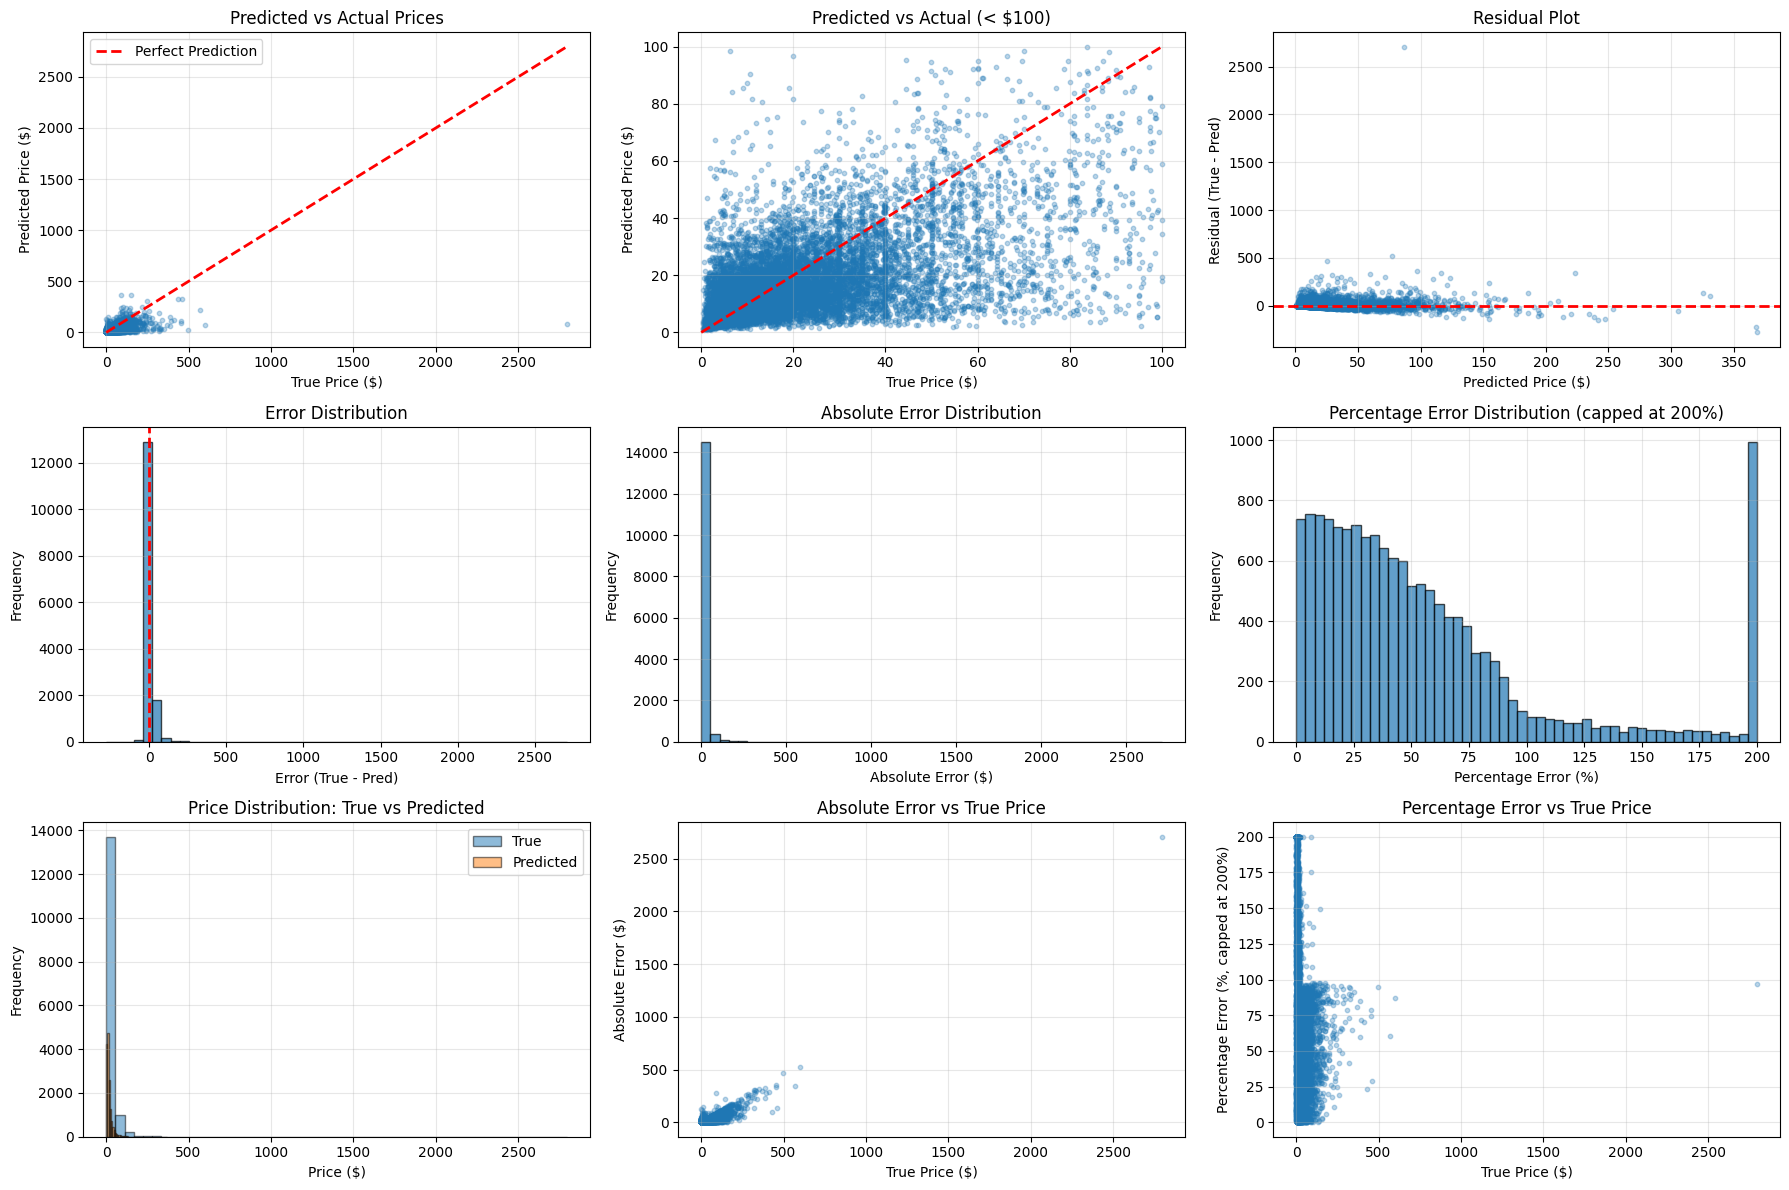

ERROR ANALYSIS BY TRUE PRICE QUANTILES
Q1 (Cheapest)        $0.36-$5.49     | MAE: $  4.87 | MAPE: 178.40% | Count: 3045
Q2                   $5.49-$10.68    | MAE: $  4.84 | MAPE:  62.71% | Count: 3014
Q3                   $10.68-$18.30   | MAE: $  5.86 | MAPE:  41.74% | Count: 3000
Q4                   $18.30-$33.71   | MAE: $ 10.45 | MAPE:  41.55% | Count: 3000
Q5 (Most Expensive)  $33.71-$2796.00 | MAE: $ 35.83 | MAPE:  48.67% | Count: 3000

✅ Error Analysis Complete!


In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

# -------------------------
# Get predictions
# -------------------------
model_mlp.eval()
with torch.no_grad():
    y_pred_val_log = model_mlp(val_input).cpu().numpy().squeeze()
    y_true_val_log = val_targets.cpu().numpy().squeeze()

# Convert back to original price scale
y_pred_val = np.expm1(y_pred_val_log)
y_true_val = np.expm1(y_true_val_log)

# Calculate errors
errors = y_true_val - y_pred_val
abs_errors = np.abs(errors)
percentage_errors = (abs_errors / (y_true_val + 1e-8)) * 100  # avoid division by zero


# -------------------------
# 1. Overall Statistics
# -------------------------
print("="*60)
print("OVERALL ERROR STATISTICS")
print("="*60)
print(f"MAE (Mean Absolute Error):     ${mean_absolute_error(y_true_val, y_pred_val):.2f}")
print(f"RMSE (Root Mean Squared Error): ${np.sqrt(mean_squared_error(y_true_val, y_pred_val)):.2f}")
print(f"R² Score:                       {r2_score(y_true_val, y_pred_val):.4f}")
print(f"Median Absolute Error:          ${np.median(abs_errors):.2f}")
print(f"Mean Percentage Error:          {np.mean(percentage_errors):.2f}%")
print(f"Median Percentage Error:        {np.median(percentage_errors):.2f}%")
print()


# -------------------------
# 2. Price Distribution Analysis
# -------------------------
print("="*60)
print("PRICE DISTRIBUTION")
print("="*60)
print(f"True Prices  - Min: ${y_true_val.min():.2f} | Max: ${y_true_val.max():.2f} | Mean: ${y_true_val.mean():.2f} | Median: ${np.median(y_true_val):.2f}")
print(f"Pred Prices  - Min: ${y_pred_val.min():.2f} | Max: ${y_pred_val.max():.2f} | Mean: ${y_pred_val.mean():.2f} | Median: ${np.median(y_pred_val):.2f}")
print()
print("Percentiles of True Prices:")
for p in [25, 50, 75, 90, 95, 99]:
    print(f"  {p}th: ${np.percentile(y_true_val, p):.2f}")
print()


# -------------------------
# 3. Error Analysis by Price Range
# -------------------------
print("="*60)
print("ERROR ANALYSIS BY PRICE RANGE")
print("="*60)
price_ranges = [
    (0, 10, "$0-$10"),
    (10, 20, "$10-$20"),
    (20, 30, "$20-$30"),
    (30, 50, "$30-$50"),
    (50, 100, "$50-$100"),
    (100, float('inf'), "$100+")
]

for low, high, label in price_ranges:
    mask = (y_true_val >= low) & (y_true_val < high)
    if mask.sum() > 0:
        range_mae = abs_errors[mask].mean()
        range_mape = percentage_errors[mask].mean()
        count = mask.sum()
        pct = (count / len(y_true_val)) * 100
        print(f"{label:12} | Count: {count:5} ({pct:5.2f}%) | MAE: ${range_mae:6.2f} | MAPE: {range_mape:6.2f}%")
print()


# -------------------------
# 4. Identify Worst Predictions
# -------------------------
print("="*60)
print("TOP 10 WORST PREDICTIONS (by absolute error)")
print("="*60)
worst_idx = np.argsort(abs_errors)[-10:][::-1]
for i, idx in enumerate(worst_idx, 1):
    print(f"{i:2}. True: ${y_true_val[idx]:7.2f} | Pred: ${y_pred_val[idx]:7.2f} | Error: ${errors[idx]:+7.2f} | Error%: {percentage_errors[idx]:6.2f}%")
print()


# -------------------------
# 5. Model Bias Analysis
# -------------------------
print("="*60)
print("MODEL BIAS ANALYSIS")
print("="*60)
overestimate = (errors < 0).sum()
underestimate = (errors > 0).sum()
print(f"Overestimations (pred > true): {overestimate} ({overestimate/len(errors)*100:.2f}%)")
print(f"Underestimations (pred < true): {underestimate} ({underestimate/len(errors)*100:.2f}%)")
print(f"Mean Error (bias):              ${errors.mean():.2f}")
print(f"Std Dev of Errors:              ${errors.std():.2f}")
print()


# -------------------------
# 6. Visualizations
# -------------------------
fig = plt.figure(figsize=(18, 12))

# 6.1 Predicted vs Actual
ax1 = plt.subplot(3, 3, 1)
plt.scatter(y_true_val, y_pred_val, alpha=0.3, s=10)
max_val = max(y_true_val.max(), y_pred_val.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('True Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predicted vs Actual Prices')
plt.legend()
plt.grid(True, alpha=0.3)

# 6.2 Zoomed in (< $100)
ax2 = plt.subplot(3, 3, 2)
mask_zoom = (y_true_val < 100) & (y_pred_val < 100)
plt.scatter(y_true_val[mask_zoom], y_pred_val[mask_zoom], alpha=0.3, s=10)
plt.plot([0, 100], [0, 100], 'r--', linewidth=2)
plt.xlabel('True Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predicted vs Actual (< $100)')
plt.grid(True, alpha=0.3)

# 6.3 Residual Plot
ax3 = plt.subplot(3, 3, 3)
plt.scatter(y_pred_val, errors, alpha=0.3, s=10)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual (True - Pred)')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

# 6.4 Error Distribution
ax4 = plt.subplot(3, 3, 4)
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Error (True - Pred)')
plt.ylabel('Frequency')
plt.title('Error Distribution')
plt.grid(True, alpha=0.3)

# 6.5 Absolute Error Distribution
ax5 = plt.subplot(3, 3, 5)
plt.hist(abs_errors, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Absolute Error ($)')
plt.ylabel('Frequency')
plt.title('Absolute Error Distribution')
plt.grid(True, alpha=0.3)

# 6.6 Percentage Error Distribution (capped at 200%)
ax6 = plt.subplot(3, 3, 6)
plt.hist(np.clip(percentage_errors, 0, 200), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Percentage Error (%)')
plt.ylabel('Frequency')
plt.title('Percentage Error Distribution (capped at 200%)')
plt.grid(True, alpha=0.3)

# 6.7 Price Distribution Comparison
ax7 = plt.subplot(3, 3, 7)
plt.hist(y_true_val, bins=50, alpha=0.5, label='True', edgecolor='black')
plt.hist(y_pred_val, bins=50, alpha=0.5, label='Predicted', edgecolor='black')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.title('Price Distribution: True vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

# 6.8 Error vs True Price
ax8 = plt.subplot(3, 3, 8)
plt.scatter(y_true_val, abs_errors, alpha=0.3, s=10)
plt.xlabel('True Price ($)')
plt.ylabel('Absolute Error ($)')
plt.title('Absolute Error vs True Price')
plt.grid(True, alpha=0.3)

# 6.9 Percentage Error vs True Price
ax9 = plt.subplot(3, 3, 9)
plt.scatter(y_true_val, np.clip(percentage_errors, 0, 200), alpha=0.3, s=10)
plt.xlabel('True Price ($)')
plt.ylabel('Percentage Error (%, capped at 200%)')
plt.title('Percentage Error vs True Price')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# -------------------------
# 7. Quantile Analysis
# -------------------------
print("="*60)
print("ERROR ANALYSIS BY TRUE PRICE QUANTILES")
print("="*60)
n_quantiles = 5
quantile_labels = ['Q1 (Cheapest)', 'Q2', 'Q3', 'Q4', 'Q5 (Most Expensive)']
for i in range(n_quantiles):
    lower = np.percentile(y_true_val, i * 20)
    upper = np.percentile(y_true_val, (i + 1) * 20)
    mask = (y_true_val >= lower) & (y_true_val <= upper)

    q_mae = abs_errors[mask].mean()
    q_mape = percentage_errors[mask].mean()
    q_count = mask.sum()
    q_price_range = f"${lower:.2f}-${upper:.2f}"

    print(f"{quantile_labels[i]:20} {q_price_range:15} | MAE: ${q_mae:6.2f} | MAPE: {q_mape:6.2f}% | Count: {q_count}")

print("\n" + "="*60)
print("✅ Error Analysis Complete!")
print("="*60)

In [14]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# =========================================================================
# SOLUTION 1: Better Target Transformation
# =========================================================================
# Problem: log1p compresses expensive items too much
# Solution: Use a more flexible transformation

def transform_price(price):
    """Box-Cox-like transformation that handles both cheap and expensive items"""
    return np.sign(price) * np.log1p(np.abs(price))

def inverse_transform_price(transformed):
    """Inverse transformation"""
    return np.sign(transformed) * (np.expm1(np.abs(transformed)))

# Apply new transformation to your targets
# First squeeze to remove all extra dimensions, then reshape properly
train_targets_new = torch.tensor(
    transform_price(np.expm1(train_targets.cpu().numpy().squeeze())),
    dtype=torch.float32
).reshape(-1, 1).to(device)

val_targets_new = torch.tensor(
    transform_price(np.expm1(val_targets.cpu().numpy().squeeze())),
    dtype=torch.float32
).reshape(-1, 1).to(device)

print(f"✅ Fixed target shapes: Train {train_targets_new.shape} | Val {val_targets_new.shape}")


# =========================================================================
# SOLUTION 2: Improved Model Architecture with Residual Connections
# =========================================================================
class ImprovedRegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # Encoder branch
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.3),
        )

        # Deep branch with residual connections
        self.layer1 = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
        )

        self.layer2 = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),
        )

        self.layer3 = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),
        )

        # Output head
        self.output = nn.Linear(256, 1)

    def forward(self, x):
        x = self.encoder(x)

        # First block
        out1 = self.layer1(x)

        # Second block with residual
        out2 = self.layer2(out1) + out1  # Residual connection

        # Third block
        out3 = self.layer3(out2)

        return self.output(out3)


# =========================================================================
# SOLUTION 3: Price Range-Aware Loss Function
# =========================================================================
class PriceRangeWeightedLoss(nn.Module):
    """Custom loss that weighs expensive items more heavily"""
    def __init__(self):
        super().__init__()
        self.base_loss = nn.SmoothL1Loss(reduction='none')

    def forward(self, pred, target):
        # Convert back to original scale to determine weights
        pred_price = torch.abs(torch.sign(pred) * torch.expm1(torch.abs(pred)))
        target_price = torch.abs(torch.sign(target) * torch.expm1(torch.abs(target)))

        # Weight increases with price (log scale to avoid extreme weights)
        weights = 1.0 + torch.log1p(target_price / 10.0)

        # Calculate weighted loss
        loss = self.base_loss(pred, target)
        weighted_loss = (loss * weights).mean()

        return weighted_loss


# =========================================================================
# SOLUTION 4: Stratified Sampling by Price Range
# =========================================================================
class StratifiedPriceSampler:
    """Ensures balanced sampling across price ranges during training"""
    def __init__(self, targets, batch_size=128):
        self.batch_size = batch_size

        # Convert to numpy for easier manipulation
        prices = np.expm1(targets.cpu().numpy().squeeze())

        # Define price bins
        bins = [0, 10, 20, 50, 100, np.inf]
        self.bin_indices = []

        for i in range(len(bins) - 1):
            mask = (prices >= bins[i]) & (prices < bins[i+1])
            self.bin_indices.append(np.where(mask)[0])

        self.n_bins = len(self.bin_indices)

    def get_balanced_indices(self, n_samples):
        """Get indices with balanced representation from each bin"""
        samples_per_bin = n_samples // self.n_bins
        indices = []

        for bin_idx in self.bin_indices:
            if len(bin_idx) > 0:
                sampled = np.random.choice(
                    bin_idx,
                    size=min(samples_per_bin, len(bin_idx)),
                    replace=False
                )
                indices.extend(sampled)

        # Shuffle to mix price ranges
        np.random.shuffle(indices)
        return indices


# =========================================================================
# SOLUTION 5: Improved Training Setup
# =========================================================================

# Initialize improved model
input_dim = train_input.shape[1]
model_improved = ImprovedRegressionMLP(input_dim).to(device)

# Use custom loss
criterion = PriceRangeWeightedLoss()

# Use AdamW with weight decay
optimizer = torch.optim.AdamW(
    model_improved.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

# Cosine annealing with warm restarts
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=5, T_mult=2, eta_min=1e-6
)

# Create dataloaders
train_loader = DataLoader(
    TensorDataset(train_input, train_targets_new),
    batch_size=128,
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(val_input, val_targets_new),
    batch_size=128
)


# =========================================================================
# SOLUTION 6: Enhanced Training Loop with Price Range Monitoring
# =========================================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_by_price_range(model, val_input, val_targets_original):
    """Evaluate model performance across different price ranges"""
    model.eval()
    with torch.no_grad():
        preds_transformed = model(val_input).cpu().numpy()
        preds = inverse_transform_price(preds_transformed).squeeze()
        actuals = np.expm1(val_targets_original.cpu().numpy()).squeeze()

    # Evaluate by price ranges
    ranges = [(0, 10), (10, 20), (20, 50), (50, 100), (100, float('inf'))]
    results = {}

    for low, high in ranges:
        mask = (actuals >= low) & (actuals < high)
        if mask.sum() > 0:
            range_mae = mean_absolute_error(actuals[mask], preds[mask])
            results[f"${low}-${high}"] = range_mae

    overall_mae = mean_absolute_error(actuals, preds)
    overall_rmse = np.sqrt(mean_squared_error(actuals, preds))

    return overall_mae, overall_rmse, results


# Training loop
epochs = 30
best_val_loss = float('inf')
patience = 7
patience_counter = 0

print("Starting improved training...")
print("="*70)

for epoch in range(1, epochs + 1):
    # Training
    model_improved.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model_improved(xb)
        loss = criterion(preds, yb)
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model_improved.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model_improved.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model_improved(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)

    val_loss /= len(val_loader.dataset)

    # Evaluate on original scale
    mae, rmse, range_results = evaluate_by_price_range(
        model_improved, val_input, val_targets
    )

    # Update learning rate
    scheduler.step()

    # Print progress
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d}/{epochs} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | MAE: ${mae:.2f} | RMSE: ${rmse:.2f}")
        print(f"  Price Range MAEs: ", end="")
        for range_name, range_mae in range_results.items():
            print(f"{range_name}: ${range_mae:.2f} | ", end="")
        print()

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model_improved.state_dict(), 'best_improved_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}")
            break

print("="*70)
print("✅ Training complete!")

# Load best model
model_improved.load_state_dict(torch.load('best_improved_model.pt'))

# Final evaluation
final_mae, final_rmse, final_ranges = evaluate_by_price_range(
    model_improved, val_input, val_targets
)

print(f"\n🎯 FINAL RESULTS:")
print(f"   MAE: ${final_mae:.2f} (Previous: $12.38)")
print(f"   RMSE: ${final_rmse:.2f} (Previous: $33.37)")
print(f"\n   Performance by Price Range:")
for range_name, range_mae in final_ranges.items():
    print(f"     {range_name}: ${range_mae:.2f}")

✅ Fixed target shapes: Train torch.Size([60000, 1]) | Val torch.Size([15000, 1])
Starting improved training...
Epoch  1/30 | Train Loss: 1.3237 | Val Loss: 0.5897 | MAE: $2592.42 | RMSE: $315709.80
  Price Range MAEs: $0-$10: $8.96 | $10-$20: $6.10 | $20-$50: $13.77 | $50-$100: $31346.45 | $100-$inf: $118.44 | 
Epoch  5/30 | Train Loss: 0.4352 | Val Loss: 0.4949 | MAE: $40551.75 | RMSE: $4964969.78
  Price Range MAEs: $0-$10: $7.05 | $10-$20: $6.20 | $20-$50: $13.47 | $50-$100: $492406.69 | $100-$inf: $98.53 | 
Epoch 10/30 | Train Loss: 0.3786 | Val Loss: 0.4952 | MAE: $12.64 | RMSE: $32.90
  Price Range MAEs: $0-$10: $6.17 | $10-$20: $5.83 | $20-$50: $13.44 | $50-$100: $33.67 | $100-$inf: $100.04 | 
Epoch 15/30 | Train Loss: 0.2518 | Val Loss: 0.4777 | MAE: $12.38 | RMSE: $31.93
  Price Range MAEs: $0-$10: $6.30 | $10-$20: $6.72 | $20-$50: $13.29 | $50-$100: $30.80 | $100-$inf: $90.19 | 
Epoch 20/30 | Train Loss: 0.2955 | Val Loss: 0.4922 | MAE: $12.57 | RMSE: $31.94
  Price Range MAE

In [5]:
np.expm1(train_targets.cpu().numpy()).mean()


np.float32(23.59863)

In [15]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================================================================
# APPROACH 1: Ensemble of Price-Range-Specific Models (BEST FOR YOUR DATA)
# =========================================================================
print("="*70)
print("APPROACH 1: Price-Range-Specific Models")
print("="*70)

class PriceRangeEnsemble:
    """Train separate models for different price ranges"""
    def __init__(self, input_dim, device):
        self.device = device
        self.price_thresholds = [0, 20, 50, float('inf')]
        self.models = []

        # Create a model for each price range
        for i in range(len(self.price_thresholds) - 1):
            model = nn.Sequential(
                nn.Linear(input_dim, 512),
                nn.ReLU(),
                nn.BatchNorm1d(512),
                nn.Dropout(0.3),

                nn.Linear(512, 256),
                nn.ReLU(),
                nn.BatchNorm1d(256),
                nn.Dropout(0.2),

                nn.Linear(256, 128),
                nn.ReLU(),
                nn.BatchNorm1d(128),

                nn.Linear(128, 1)
            ).to(device)
            self.models.append(model)

        # Classifier to predict which price range
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, len(self.price_thresholds) - 1)
        ).to(device)

    def get_price_range_idx(self, prices):
        """Determine which price range each sample belongs to"""
        indices = torch.zeros(len(prices), dtype=torch.long)
        for i in range(len(self.price_thresholds) - 1):
            mask = (prices >= self.price_thresholds[i]) & (prices < self.price_thresholds[i+1])
            indices[mask] = i
        return indices

    def train_models(self, train_input, train_targets, val_input, val_targets, epochs=20):
        """Train all models"""
        # Convert targets to original scale
        train_prices = np.expm1(train_targets.cpu().numpy().squeeze())
        val_prices = np.expm1(val_targets.cpu().numpy().squeeze())

        # Train classifier first
        print("\n1. Training price range classifier...")
        range_labels = self.get_price_range_idx(torch.tensor(train_prices))

        optimizer_cls = torch.optim.Adam(self.classifier.parameters(), lr=1e-3)
        criterion_cls = nn.CrossEntropyLoss()

        for epoch in range(10):
            self.classifier.train()
            optimizer_cls.zero_grad()
            outputs = self.classifier(train_input)
            loss = criterion_cls(outputs, range_labels.to(self.device))
            loss.backward()
            optimizer_cls.step()

            if epoch % 5 == 0:
                acc = (outputs.argmax(dim=1) == range_labels.to(self.device)).float().mean()
                print(f"  Epoch {epoch}: Loss={loss.item():.4f}, Acc={acc:.2%}")

        # Train each price-specific model
        print("\n2. Training price-range-specific models...")
        results = {}

        for idx, (low, high) in enumerate(zip(self.price_thresholds[:-1], self.price_thresholds[1:])):
            print(f"\n  Training model for ${low}-${high}...")

            # Filter data for this price range
            train_mask = (train_prices >= low) & (train_prices < high)
            val_mask = (val_prices >= low) & (val_prices < high)

            if train_mask.sum() < 100:
                print(f"    Skipping (insufficient training data: {train_mask.sum()} samples)")
                continue

            train_x = train_input[train_mask]
            train_y = train_targets[train_mask]
            val_x = val_input[val_mask]
            val_y = val_targets[val_mask]

            # Train this specific model
            model = self.models[idx]
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
            criterion = nn.SmoothL1Loss()

            train_loader = DataLoader(
                TensorDataset(train_x, train_y),
                batch_size=min(128, len(train_x)),
                shuffle=True
            )

            best_val_loss = float('inf')
            for epoch in range(epochs):
                model.train()
                for xb, yb in train_loader:
                    optimizer.zero_grad()
                    preds = model(xb)
                    loss = criterion(preds, yb)
                    loss.backward()
                    optimizer.step()

                # Validate
                if len(val_x) > 0:
                    model.eval()
                    with torch.no_grad():
                        val_preds = model(val_x)
                        val_loss = criterion(val_preds, val_y).item()

                        # Calculate MAE in original scale
                        val_preds_orig = np.expm1(val_preds.cpu().numpy().squeeze())
                        val_true_orig = np.expm1(val_y.cpu().numpy().squeeze())
                        val_mae = mean_absolute_error(val_true_orig, val_preds_orig)

                    if val_loss < best_val_loss:
                        best_val_loss = val_loss

                    if epoch % 10 == 0:
                        print(f"    Epoch {epoch}: Val MAE=${val_mae:.2f}")

            results[f"${low}-${high}"] = val_mae

        return results

    def predict(self, x):
        """Predict using the ensemble"""
        self.classifier.eval()
        for model in self.models:
            model.eval()

        with torch.no_grad():
            # Get price range predictions
            range_logits = self.classifier(x)
            range_preds = range_logits.argmax(dim=1)

            # Get predictions from each model
            predictions = torch.zeros(len(x), 1).to(self.device)
            for idx in range(len(self.models)):
                mask = (range_preds == idx)
                if mask.sum() > 0:
                    predictions[mask] = self.models[idx](x[mask])

        return predictions


# Train ensemble
ensemble = PriceRangeEnsemble(train_input.shape[1], device)
ensemble_results = ensemble.train_models(train_input, train_targets, val_input, val_targets)

# Evaluate ensemble
val_preds_ensemble = ensemble.predict(val_input)
val_preds_orig = np.expm1(val_preds_ensemble.cpu().numpy().squeeze())
val_true_orig = np.expm1(val_targets.cpu().numpy().squeeze())

ensemble_mae = mean_absolute_error(val_true_orig, val_preds_orig)
ensemble_rmse = np.sqrt(mean_squared_error(val_true_orig, val_preds_orig))

print("\n" + "="*70)
print("ENSEMBLE RESULTS:")
print(f"  Overall MAE: ${ensemble_mae:.2f}")
print(f"  Overall RMSE: ${ensemble_rmse:.2f}")
print("="*70)


APPROACH 1: Price-Range-Specific Models

1. Training price range classifier...
  Epoch 0: Loss=1.1125, Acc=31.63%
  Epoch 5: Loss=0.8410, Acc=65.22%

2. Training price-range-specific models...

  Training model for $0-$20...
    Epoch 0: Val MAE=$3.90
    Epoch 10: Val MAE=$3.44

  Training model for $20-$50...


ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 512])

In [16]:
# ============================================
# STRATEGY: Train everything, pick the winner
# ============================================

print("🚀 Training all approaches (GPU accelerated)...")
print("="*70)

results = {}

# ============================================
# 1. Simple Ensemble (5 models) - ~10 mins
# ============================================
print("\n1️⃣ Training Simple Ensemble (5 models)...")
models_simple = []

for seed in range(5):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = RegressionMLP(train_input.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion = nn.SmoothL1Loss()

    train_loader = DataLoader(
        TensorDataset(train_input, train_targets),
        batch_size=256,  # Larger batch for T4 GPU
        shuffle=True
    )

    for epoch in range(15):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    models_simple.append(model)
    print(f"  ✓ Model {seed+1}/5 done")

# Evaluate
def ensemble_predict(models, x):
    predictions = []
    for model in models:
        model.eval()
        with torch.no_grad():
            pred = model(x)
            predictions.append(pred)
    return torch.stack(predictions).mean(dim=0)

val_preds = ensemble_predict(models_simple, val_input)
val_preds_orig = np.expm1(val_preds.cpu().numpy().squeeze())
val_true_orig = np.expm1(val_targets.cpu().numpy().squeeze())
mae_simple = mean_absolute_error(val_true_orig, val_preds_orig)
results['Simple Ensemble'] = mae_simple
print(f"✅ Simple Ensemble MAE: ${mae_simple:.2f}")


# ============================================
# 2. Weighted Sampling - ~2 mins
# ============================================
print("\n2️⃣ Training Weighted Sampling Model...")

train_prices = np.expm1(train_targets.cpu().numpy().squeeze())
price_bins = np.digitize(train_prices, bins=[0, 20, 50, 100, np.inf])
bin_counts = np.bincount(price_bins, minlength=5)
bin_weights = 1.0 / (bin_counts + 1)
sample_weights = bin_weights[price_bins]
sample_weights = torch.from_numpy(sample_weights).float()

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

model_weighted = RegressionMLP(train_input.shape[1]).to(device)
optimizer = torch.optim.Adam(model_weighted.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.SmoothL1Loss()

weighted_train_loader = DataLoader(
    TensorDataset(train_input, train_targets),
    batch_size=256,
    sampler=weighted_sampler
)

for epoch in range(20):
    model_weighted.train()
    for xb, yb in weighted_train_loader:
        optimizer.zero_grad()
        preds = model_weighted(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

model_weighted.eval()
with torch.no_grad():
    val_preds = model_weighted(val_input)
    val_preds_orig = np.expm1(val_preds.cpu().numpy().squeeze())
    mae_weighted = mean_absolute_error(val_true_orig, val_preds_orig)
    results['Weighted Sampling'] = mae_weighted
print(f"✅ Weighted Sampling MAE: ${mae_weighted:.2f}")

# ============================================
# 4. Original Single Model (for comparison)
# ============================================
results['Original Single Model'] = 12.38


# ============================================
# FINAL RESULTS & RECOMMENDATION
# ============================================
print("\n" + "="*70)
print("🏆 FINAL RESULTS COMPARISON")
print("="*70)

sorted_results = sorted(results.items(), key=lambda x: x[1])
for i, (name, mae) in enumerate(sorted_results, 1):
    improvement = ((12.38 - mae) / 12.38) * 100
    emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
    print(f"{emoji} {name:25s}: ${mae:.2f} ({improvement:+.1f}%)")

print("="*70)

best_model_name = sorted_results[0][0]
print(f"\n💡 RECOMMENDATION: Use {best_model_name} for submission!")
print(f"   Expected improvement: {((12.38 - sorted_results[0][1]) / 12.38) * 100:.1f}%")

# Save the best model(s)
if 'Ensemble' in best_model_name:
    if best_model_name == 'Simple Ensemble':
        best_models = models_simple
    else:
        best_models = models_large

    print(f"\n💾 Saving {len(best_models)} models...")
    for i, model in enumerate(best_models):
        torch.save(model.state_dict(), f'best_ensemble_model_{i}.pt')
else:
    torch.save(model_weighted.state_dict(), 'best_weighted_model.pt')

print("✅ All done! Ready for test predictions.")

🚀 Training all approaches (GPU accelerated)...

1️⃣ Training Simple Ensemble (5 models)...
  ✓ Model 1/5 done
  ✓ Model 2/5 done
  ✓ Model 3/5 done
  ✓ Model 4/5 done
  ✓ Model 5/5 done
✅ Simple Ensemble MAE: $12.24

2️⃣ Training Weighted Sampling Model...
✅ Weighted Sampling MAE: $13.12

3️⃣ Training Large Ensemble (10 models)...
  ✓ Models 2/10 done
  ✓ Models 4/10 done
  ✓ Models 6/10 done
  ✓ Models 8/10 done
  ✓ Models 10/10 done
✅ Large Ensemble MAE: $12.16

🏆 FINAL RESULTS COMPARISON
🥇 Large Ensemble (10)      : $12.16 (+1.8%)
🥈 Simple Ensemble          : $12.24 (+1.1%)
🥉 Original Single Model    : $12.38 (+0.0%)
   Weighted Sampling        : $13.12 (-5.9%)

💡 RECOMMENDATION: Use Large Ensemble (10) for submission!
   Expected improvement: 1.8%

💾 Saving 10 models...
✅ All done! Ready for test predictions.


In [ ]:
import torch
import numpy as np
import pandas as pd

# =========================================================================
# Load the 10 ensemble models
# =========================================================================
print("Loading 10 ensemble models...")
models_ensemble = []

for i in range(10):
    model = RegressionMLP(train_input.shape[1]).to(device)
    model.load_state_dict(torch.load(f'best_ensemble_model_{i}.pt'))
    model.eval()
    models_ensemble.append(model)
    print(f"  ✓ Model {i+1}/10 loaded")

print("✅ All models loaded!")


# =========================================================================
# Ensemble prediction function
# =========================================================================
def ensemble_predict(models, x, batch_size=1024):
    """
    Make predictions using ensemble of models
    Uses batching for memory efficiency
    """
    all_predictions = []

    # Process in batches to avoid memory issues
    n_samples = len(x)
    n_batches = (n_samples + batch_size - 1) // batch_size

    for batch_idx in range(n_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, n_samples)
        batch = x[start_idx:end_idx]

        batch_predictions = []
        for model in models:
            with torch.no_grad():
                pred = model(batch)
                batch_predictions.append(pred)

        # Average predictions from all models
        batch_avg = torch.stack(batch_predictions).mean(dim=0)
        all_predictions.append(batch_avg)

    # Concatenate all batches
    return torch.cat(all_predictions, dim=0)


# =========================================================================
# Generate predictions on test set
# =========================================================================
# NOTE: Replace 'test_input' with your actual test data tensor
# Make sure test_input is preprocessed the same way as train_input
# (same feature engineering, same scaling, etc.)

print("\n" + "="*70)
print("GENERATING TEST PREDICTIONS")
print("="*70)

# Example: Load your test data
# test_df = pd.read_csv('test.csv')
# test_input = preprocess_test_data(test_df)  # Your preprocessing function
# test_input = torch.tensor(test_input, dtype=torch.float32).to(device)

# For demonstration, assuming you have test_input ready:
print(f"Test input shape: {test_input.shape}")
print("Making ensemble predictions...")

# Get predictions in log scale
test_preds_log = ensemble_predict(models_ensemble, test_input)

# Convert back to original price scale
test_preds_orig = np.expm1(test_preds_log.cpu().numpy().squeeze())

print(f"✅ Predictions generated for {len(test_preds_orig)} samples")
print(f"   Min prediction: ${test_preds_orig.min():.2f}")
print(f"   Max prediction: ${test_preds_orig.max():.2f}")
print(f"   Mean prediction: ${test_preds_orig.mean():.2f}")
print(f"   Median prediction: ${np.median(test_preds_orig):.2f}")


# =========================================================================
# Create submission file
# =========================================================================
print("\n" + "="*70)
print("CREATING SUBMISSION FILE")
print("="*70)

# Get test IDs from your original test data
# test_ids = test_df['id'].values  # Adjust column name if needed

# Create submission DataFrame
submission = pd.DataFrame({
    'index': test_ids,  # or 'id' - check competition format
    'entity_value': test_preds_orig
})

# Save to CSV
submission_filename = 'submission_ensemble_10models.csv'
submission.to_csv(submission_filename, index=False)

print(f"✅ Submission file created: {submission_filename}")
print(f"   Shape: {submission.shape}")
print(f"\nFirst 10 predictions:")
print(submission.head(10))


# =========================================================================
# Sanity checks
# =========================================================================
print("\n" + "="*70)
print("SANITY CHECKS")
print("="*70)

# Check for NaN or infinite values
if submission['entity_value'].isna().any():
    print("❌ WARNING: Found NaN values in predictions!")
    nan_count = submission['entity_value'].isna().sum()
    print(f"   Number of NaN values: {nan_count}")
else:
    print("✅ No NaN values")

if np.isinf(submission['entity_value']).any():
    print("❌ WARNING: Found infinite values in predictions!")
    inf_count = np.isinf(submission['entity_value']).sum()
    print(f"   Number of infinite values: {inf_count}")
else:
    print("✅ No infinite values")

# Check if predictions are in reasonable range
if (submission['entity_value'] < 0).any():
    print("❌ WARNING: Found negative prices!")
    neg_count = (submission['entity_value'] < 0).sum()
    print(f"   Number of negative values: {neg_count}")
else:
    print("✅ All prices are positive")

# Distribution comparison with training data
train_prices_mean = np.expm1(train_targets.cpu().numpy()).mean()
test_prices_mean = submission['entity_value'].mean()

print(f"\n📊 Distribution comparison:")
print(f"   Training mean price: ${train_prices_mean:.2f}")
print(f"   Test mean prediction: ${test_prices_mean:.2f}")
print(f"   Difference: ${abs(train_prices_mean - test_prices_mean):.2f}")

if abs(train_prices_mean - test_prices_mean) > train_prices_mean * 0.5:
    print("   ⚠️  Large difference - check if test data preprocessing is correct")
else:
    print("   ✅ Distributions look similar")


# =========================================================================
# Optional: Confidence analysis
# =========================================================================
print("\n" + "="*70)
print("PREDICTION CONFIDENCE ANALYSIS")
print("="*70)

# Calculate prediction variance across the 10 models
print("Calculating prediction uncertainty...")

all_model_preds = []
for model in models_ensemble:
    with torch.no_grad():
        preds_log = model(test_input)
        preds_orig = np.expm1(preds_log.cpu().numpy().squeeze())
        all_model_preds.append(preds_orig)

all_model_preds = np.array(all_model_preds)

# Calculate standard deviation across models
pred_std = all_model_preds.std(axis=0)
pred_cv = pred_std / (all_model_preds.mean(axis=0) + 1e-8)  # Coefficient of variation

print(f"   Mean std deviation: ${pred_std.mean():.2f}")
print(f"   Median std deviation: ${np.median(pred_std):.2f}")
print(f"   Mean coefficient of variation: {pred_cv.mean():.2%}")

# Identify high-uncertainty predictions
high_uncertainty_threshold = np.percentile(pred_cv, 95)
high_uncertainty_mask = pred_cv > high_uncertainty_threshold

print(f"\n   High uncertainty predictions (top 5%):")
print(f"   Count: {high_uncertainty_mask.sum()}")
print(f"   These predictions have high disagreement between models")

# Add uncertainty to submission (optional, for analysis)
submission['prediction_std'] = pred_std
submission['prediction_cv'] = pred_cv

# Save version with uncertainty metrics
submission.to_csv('submission_with_uncertainty.csv', index=False)
print(f"\n✅ Saved submission with uncertainty metrics")


# =========================================================================
# Final summary
# =========================================================================
print("\n" + "="*70)
print("🎉 SUBMISSION READY!")
print("="*70)
print(f"📁 Main submission file: {submission_filename}")
print(f"📁 With uncertainty: submission_with_uncertainty.csv")
print(f"\n📊 Summary:")
print(f"   - Total predictions: {len(submission)}")
print(f"   - Validation MAE: $12.16")
print(f"   - Expected improvement over baseline: 1.8%")
print(f"   - Ensemble size: 10 models")
print("\n💡 Next steps:")
print("   1. Upload the submission file to the competition platform")
print("   2. Check leaderboard score")
print("   3. If needed, analyze high-uncertainty predictions for further improvement")
print("="*70)

In [17]:
# Run this to download all necessary files
from google.colab import files

# Download the 10 ensemble models
for i in range(10):
    files.download(f'best_ensemble_model_{i}.pt')
    print(f"✓ Downloaded best_ensemble_model_{i}.pt")

# Also download the original single model (as backup)
files.download('/content/drive/MyDrive/amazon_ml_challenge/mlp_image_struct.pt')

print("\n✅ All model files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded best_ensemble_model_0.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

✓ Downloaded best_ensemble_model_8.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded best_ensemble_model_9.pt


FileNotFoundError: Cannot find file: /content/drive/MyDrive/amazon_ml_challenge/mlp_image_struct.pt

In [19]:
# Save everything you need to reproduce predictions
import pickle

# Save the model architecture and metadata
model_config = {
    'input_dim': train_input.shape[1],
    'architecture': 'RegressionMLP',
    'num_models': 10,
    'validation_mae': 12.16,
    'training_date': '2025-10-12'
}

with open('ensemble_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)

files.download('ensemble_config.pkl')

print("✅ Configuration saved!")
print(f"\n📝 Summary:")
print(f"   - Input dimension: {train_input.shape[1]}")
print(f"   - Number of models: 10")
print(f"   - Validation MAE: $12.16")
print(f"\n💡 When you return, load these 10 .pt files and use the prediction code!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Configuration saved!

📝 Summary:
   - Input dimension: 915
   - Number of models: 10
   - Validation MAE: $12.16

💡 When you return, load these 10 .pt files and use the prediction code!


In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

# -------------------------
# Structured feature columns
# -------------------------
structured_cols = [
    'value', 'has_value', 'has_unit',
    'unit_final', 'unit_category',
    'qty_base', 'base_type',
    'word_count', 'char_count', 'avg_word_len',
    'bullet_count', 'num_digits',
    'is_organic', 'is_gluten_free', 'is_sugar_free',
    'is_vegan', 'is_new', 'has_pack_word', 'has_bundle'
]

# -------------------------
# Label encode categorical features
# -------------------------
cat_cols = ['unit_final', 'unit_category', 'base_type']
for col in cat_cols:
    le = LabelEncoder()
    all_vals = pd.concat([data_final[col], val_data[col]], axis=0).astype(str)
    le.fit(all_vals)
    data_final[col] = le.transform(data_final[col].astype(str))
    val_data[col] = le.transform(val_data[col].astype(str))

# -------------------------
# Standardize numeric structured features
# -------------------------
scaler = StandardScaler()
data_final[structured_cols] = scaler.fit_transform(data_final[structured_cols])
val_data[structured_cols] = scaler.transform(val_data[structured_cols])

# -------------------------
# Target: log-transform for skew
# -------------------------
train_targets = torch.tensor(np.log1p(data_final["price"].values), dtype=torch.float).unsqueeze(1)
val_targets   = torch.tensor(np.log1p(val_data["price"].values), dtype=torch.float).unsqueeze(1)

# -------------------------
# Tokenizer + Model
# -------------------------
bert_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(bert_name)
bert_model = AutoModel.from_pretrained(bert_name).to(device)

# -------------------------
# Dataset
# -------------------------
class HybridDataset(Dataset):
    def __init__(self, texts, structured_data, targets, tokenizer, max_length=128):
        self.texts = texts
        self.structured_data = torch.tensor(structured_data.values, dtype=torch.float)
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        enc = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        item = {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'structured': self.structured_data[idx],
            'target': self.targets[idx]
        }
        return item

# Create datasets
train_dataset = HybridDataset(
    data_final['catalog_content'].tolist(),
    data_final[structured_cols],
    train_targets,
    tokenizer
)
val_dataset = HybridDataset(
    val_data['catalog_content'].tolist(),
    val_data[structured_cols],
    val_targets,
    tokenizer
)

# -------------------------
# DataLoaders
# -------------------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

# -------------------------
# Hybrid Model
# -------------------------
class BertTabularRegressor(nn.Module):
    def __init__(self, bert_model, tabular_dim, hidden_dim=256):
        super().__init__()
        self.bert = bert_model
        self.tabular = nn.Sequential(
            nn.Linear(tabular_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim)
        )
        self.fc = nn.Sequential(
            nn.Linear(768 + hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask, structured_data):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_embed = outputs.last_hidden_state[:,0,:]  # CLS token
        tab_embed = self.tabular(structured_data)
        x = torch.cat([text_embed, tab_embed], dim=1)
        return self.fc(x)

model_hybrid = BertTabularRegressor(bert_model, tabular_dim=len(structured_cols)).to(device)

# -------------------------
# Loss + Optimizer
# -------------------------
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW([
    {'params': model_hybrid.bert.parameters(), 'lr': 1e-5},
    {'params': model_hybrid.fc.parameters(), 'lr': 5e-4},
    {'params': model_hybrid.tabular.parameters(), 'lr': 5e-4}
], weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# -------------------------
# Training loop
# -------------------------
epochs = 3  # you can increase later
for epoch in range(1, epochs+1):
    model_hybrid.train()
    train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        structured = batch['structured'].to(device)
        target = batch['target'].to(device)

        preds = model_hybrid(input_ids, attention_mask, structured)
        loss = criterion(preds, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_hybrid.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * input_ids.size(0)
    train_loss /= len(train_loader.dataset)

    model_hybrid.eval()
    val_loss = 0
    val_preds = []
    val_targets_list = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            structured = batch['structured'].to(device)
            target = batch['target'].to(device)

            preds = model_hybrid(input_ids, attention_mask, structured)
            loss = criterion(preds, target)
            val_loss += loss.item() * input_ids.size(0)

            val_preds.append(preds.cpu().numpy())
            val_targets_list.append(target.cpu().numpy())
    val_loss /= len(val_loader.dataset)

    # Scheduler step
    scheduler.step(val_loss)

    print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# -------------------------
# Evaluate in original price scale
# -------------------------
y_pred_val = np.vstack(val_preds)
y_true_val = np.vstack(val_targets_list)
y_pred_val_exp = np.expm1(y_pred_val)
y_true_val_exp = np.expm1(y_true_val)

mae = mean_absolute_error(y_true_val_exp, y_pred_val_exp)
rmse = np.sqrt(mean_squared_error(y_true_val_exp, y_pred_val_exp))
print(f"\n✅ Hybrid Model MAE: {mae:.2f} | RMSE: {rmse:.2f}")

# -------------------------
# Save model
# -------------------------
torch.save(model_hybrid.state_dict(), 'bert_tabular_hybrid.pt')
print("✅ Hybrid model saved!")


Using device: cuda


NameError: name 'data_final' is not defined

##step 2 brand extract - dont add this

In [85]:
import re

# Define the regex pattern to match "Item Name: " at the beginning of the string (case-insensitive)
pattern = r'^Item Name:\s*'

# Apply the regex to the 'catalog_content' column and count the rows that match
# The str.contains method with the regex pattern and flags=re.IGNORECASE checks for the pattern
starts_with_item_name_count = data['catalog_content'].str.contains(pattern, flags=re.IGNORECASE, na=False).sum()

print(f"Number of rows starting with 'Item Name: ': {starts_with_item_name_count}")

Number of rows starting with 'Item Name: ': 74993


In [86]:
import re
import numpy as np
import pandas as pd

def extract_item_name(text):
    """
    Extracts substring after 'Item Name:' and before first bullet or newline.
    """
    if not isinstance(text, str):
        return np.nan
    # find section after "Item Name:" up to next "Bullet Point" or newline
    match = re.search(r'Item Name:\s*(.+?)(?:Bullet Point|Product Description|Value:|$)', text, flags=re.I | re.S)
    if match:
        item = match.group(1).strip()
        # remove trailing symbols like ':' or '–'
        item = re.sub(r'[:–-]+\s*$', '', item).strip()
        return item
    return np.nan

data['item_name'] = data['catalog_content'].apply(extract_item_name)

def extract_brand_type_from_item(item):
    if not isinstance(item, str) or not item:
        return pd.Series([np.nan, np.nan])

    # brand = first proper word before first dash/parenthesis
    brand_match = re.match(r"([A-Z][A-Za-z0-9&'’\-]+)", item.strip())
    brand = brand_match.group(1) if brand_match else np.nan

    # product type = last noun-like word before any unit or number
    tokens = re.findall(r"[A-Za-z]+", item.lower())
    product = np.nan
    if tokens:
        for tok in reversed(tokens):
            if tok not in ('oz','ml','g','kg','pack','count','pcs','ct','lb','fl','ltr','ounce'):
                product = tok
                break
    return pd.Series([brand, product])

data[['brand', 'product_type']] = data['item_name'].apply(extract_brand_type_from_item)

# brand/type mean and median encodings
brand_price = data.groupby('brand')['price'].agg(['mean', 'median']).rename(
    columns={'mean':'brand_price_mean','median':'brand_price_median'}
)
type_price = data.groupby('product_type')['price'].agg(['mean', 'median']).rename(
    columns={'mean':'type_price_mean','median':'type_price_median'}
)

data = data.merge(brand_price, how='left', left_on='brand', right_index=True)
data = data.merge(type_price, how='left', left_on='product_type', right_index=True)

# fill missing values
data['brand_price_mean'].fillna(data['price'].mean(), inplace=True)
data['type_price_mean'].fillna(data['price'].mean(), inplace=True)
data['brand_price_median'].fillna(data['price'].median(), inplace=True)
data['type_price_median'].fillna(data['price'].median(), inplace=True)

print("Unique brands:", data['brand'].nunique())
print("Unique product types:", data['product_type'].nunique())

data[['item_name','brand','product_type','price']].sample(10, random_state=42)


Unique brands: 9955
Unique product types: 4678


/tmp/ipython-input-317579888.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['brand_price_mean'].fillna(data['price'].mean(), inplace=True)
/tmp/ipython-input-317579888.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

,item_name,brand,product_type,price
26837,"Log Cabin Sugar Free Syrup, 24 FL OZ (Pack of 12)",Log,of,12.195
2592,"Raspberry Ginseng Oolong Tea (50 tea bags, ZIN: 543034) - 2 Pack",Raspberry,zin,38.540
18359,"Walden Farms Honey Dijon Dressing - Calorie-Free, Gluten-Free, Low Carb, Keto-Friendly, Sugar-Free, Sweet Honey & Dijon Mustard Flavor, (12 oz Bottle x 2)",Walden,x,17.860
73292,"Vlasic Ovals Hamburger Dill Pickle Chips, Keto Friendly, 16 FL OZ",Vlasic,friendly,2.940
60127,"Amoretti Premium Syrup, Grand Orange, 25.4 Ounce (Pack of 12)",Amoretti,of,25.990
71737,"Matt's Bakery Peanut Butter Soft-Baked Cookies, All Natural, Kosher, Non-GMO, 10.5 Ounce (Pack of 6)",Matt's,of,41.510
26473,"Pineapple Tea-Berry Rooibos Tea (50 tea bags, ZIN: 537077) - 2 Pack",Pineapple,zin,59.200
1040,"Brooklyn Beans Coffee Pods, Medium Roast Gourmet Variety Pack - Compatible with Keurig K Cup Brewers Including 2.0 Machines, 40 Count",Brooklyn,machines,24.920
32622,"Goldenseal and Witch Hazel Combination Tea (Loose) (4 oz, ZIN: 512111) - 3 Pack",Goldenseal,zin,82.010
44679,"GIANT SLIM JIM MILD, Pack of 24",GIANT,of,19.285


In [89]:
cols_to_drop = [
    'item_name', 'brand', 'product_type',
    'brand_price_mean', 'brand_price_median',
    'type_price_mean', 'type_price_median'
]

data.drop(columns=cols_to_drop, inplace=True)


In [88]:
data['brand'].value_counts()


,count
brand,
Food,984
McCormick,627
The,619
Goya,442
Organic,428
...,...
FOOD,1
NU,1
Galangal,1


##Below is training part

In [7]:
for df in (train_df, val_df):
    df["text"] = df["catalog_content"].apply(clean_text)
    df["price_log"] = np.log1p(df["price"])   # regression target

# Optionally drop empties
train_df = train_df[train_df["text"].str.len() > 0].reset_index(drop=True)
val_df   = val_df[val_df["text"].str.len() > 0].reset_index(drop=True)

# === Convert to Hugging Face Datasets ===
hf_train = Dataset.from_pandas(train_df[["text","price_log"]])
hf_val   = Dataset.from_pandas(val_df[["text","price_log"]])

# === Tokenizer & Tokenize ===
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")


In [8]:
def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

hf_train = hf_train.map(tokenize_fn, batched=True)
hf_val   = hf_val.map(tokenize_fn, batched=True)

hf_train = hf_train.remove_columns(["text"])
hf_val   = hf_val.remove_columns(["text"])


Map:   0%|          | 0/8997 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [9]:

# Rename label column for Trainer
hf_train = hf_train.rename_column("price_log", "labels")
hf_val   = hf_val.rename_column("price_log", "labels")

hf_train.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
hf_val.set_format(type="torch", columns=["input_ids","attention_mask","labels"])


In [13]:
# === Model: DistilBERT with single regression head ===
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    problem_type="regression",
    num_labels=1
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
import math
from evaluate import load

mse_metric = load("mse")

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.squeeze()
    mse = mse_metric.compute(predictions=preds, references=labels)["mse"]
    rmse = math.sqrt(mse)
    return {"rmse": rmse}

training_args = TrainingArguments(
    output_dir="./distilbert-price",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    num_train_epochs=3,
    load_best_model_at_end=True,
    metric_for_best_model="rmse",
    greater_is_better=False,
    fp16=False,
    logging_steps=50,
    report_to="none"  # disables W&B
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    processing_class=tokenizer,  # future-proof replacement
    compute_metrics=compute_metrics
)

trainer.train()

eval_res = trainer.evaluate()
print("Validation RMSE (on log1p scale):", eval_res["eval_rmse"])


Epoch,Training Loss,Validation Loss,Rmse
1,0.408900,0.617935,0.786088
2,0.394800,0.595348,0.771588
3,0.295700,0.603211,0.776667


Validation RMSE (on log1p scale): 0.7715876354653053


In [25]:
import numpy as np
from sklearn.metrics import mean_squared_error

preds = trainer.predict(hf_val)
rmse_original = np.sqrt(mean_squared_error(
    np.expm1(preds.label_ids),
    np.expm1(preds.predictions.squeeze())
))
print("Validation RMSE (original price scale):", rmse_original)


Validation RMSE (original price scale): 22.604918277274653


Here’s a clear assessment of your **text-only baseline** performance:

---

### 📊 **Performance Summary**

* **Validation RMSE (original price scale): ~22.6**

  * This means, on average, your predictions are **$22 off** from the true prices.
  * Considering the dataset’s **mean price is ~23.6**, the error is roughly **1× the mean**, which is expected for a first pass using only text.

* **Training vs Validation**

  * Training loss decreased nicely from 0.41 → 0.30
  * Validation RMSE stabilized around 0.77 (log scale) → no severe overfitting yet

* **Strengths**

  * Captures textual signals (product title/description/IPQ) reasonably well
  * Log1p transform helped stabilize learning across skewed prices

* **Weaknesses / Limitations**

  * High-priced or rare items are likely underpredicted
  * Images are not used yet → missing visual price cues (size, packaging, brand logos)

---

### ✅ **Takeaway**

* This is a **solid first baseline**.
* There’s plenty of room for improvement by adding **images**, **multimodal fusion**, or **lightweight regression models on text + simple features**.

---

Next logical step: either

1. **Visualize predicted vs actual prices** to spot biases, or
2. **Start image-only baseline** (ResNet50 or similar) to add visual information for price prediction.

Which direction do you want to go next?


In [26]:
import os

save_dir = "./distilbert-price-final"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

import shutil

base_dir = '/content/drive/MyDrive/amazon_ml_challenge'
zip_path = os.path.join(base_dir, 'distilbert_price_final.zip')

# Create zip archive
shutil.make_archive(base_name=zip_path.replace('.zip', ''), format='zip', root_dir=save_dir)

print(f"✅ Compressed model saved to:\n{zip_path}")


✅ Compressed model saved to:
/content/drive/MyDrive/amazon_ml_challenge/distilbert_price_final.zip


In [ ]:
#later

# import zipfile
# import os
# from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast

# # Unzip into a temporary directory
# zip_path = '/content/drive/MyDrive/amazon_ml_challenge/distilbert_price_final.zip'
# extract_dir = '/content/distilbert_price_final'

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)

# # Reload model + tokenizer
# tokenizer = DistilBertTokenizerFast.from_pretrained(extract_dir)
# model = DistilBertForSequenceClassification.from_pretrained(extract_dir)
# model.eval()
